# **Step2. 상품리뷰분석 Agent2**

## **0. 미션**

### 미션③ : LangSmith 기반 모니터링 시스템 구축
* [필수] 실행 Trace : 설정 및 관측 결과 확인
* [선택항목] 다음 항목은 예시 입니다.
	* 평가 : 데이터셋 구성, 평가 지표 설정 및 확인
	* 실패(혹은 오류) 케이스를 만들고 추적 및 원인 분석


### 미션④ : Agent 고도화
* [필수] Supervisor 중심 반복 제어
* [필수] DB에 쌓인 리뷰 예측 batch 처리
* [선택항목] 다음은 예시 입니다.
    - 각 에이전트 고도화 : 성능/정확도를 높이기 위한 프롬프트 개선 등
    - HITL 노드 설계 : 특정 조건 시 Human Review 전환
    - 그 외 팀 내에서 추가 기능 검토 후 구현 가능


### 미션⑤ : 대시보드 만들기(streamlit 기반)
* [필수] 기본 대시보드 : 리뷰 결과 집계 및 개별 정보 조회
* [선택항목] 다음은 예시 입니다.
    - 감성분석 결과에 대한 다양한 시각화
    -  Insight Agent 추가 : 요약 리포트 생성 및 개선 제안 도출
    - 그 외 팀 내에서 추가 기능 검토 후 구현 가능


### 워크플로우 V2.0

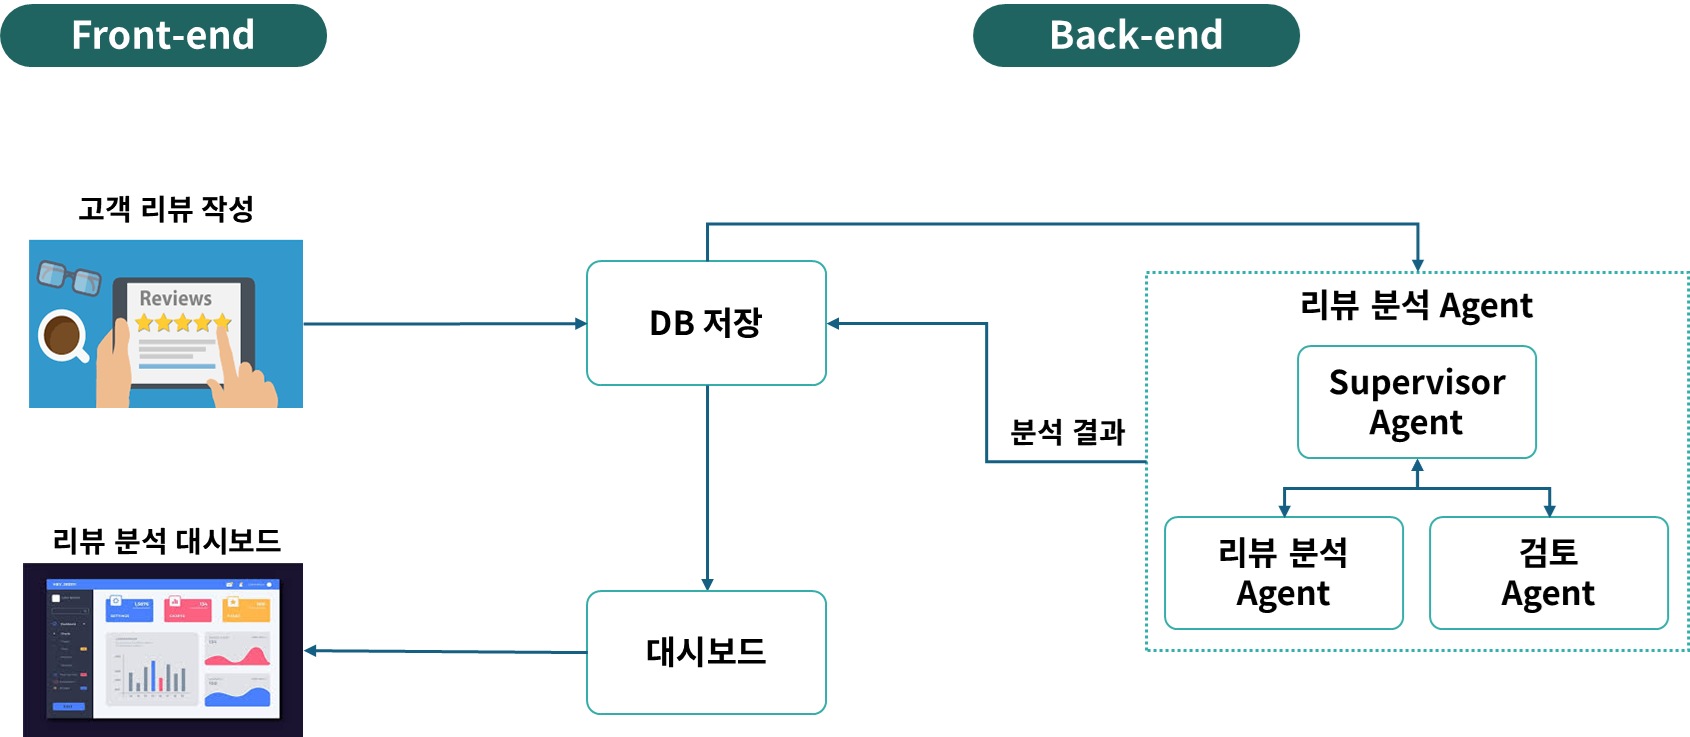

## **1. 환경준비**

### (1) 구글 드라이브

* 구글 드라이브 폴더 생성
    * 새 폴더 `proj2_agent`를 생성(이미 만들었다면 skip)
    * 제공 받은 파일을 업로드

* 구글 드라이브 연결

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### (2) 라이브러리

* 필요한 라이브러리 설치

In [3]:
!pip install -q langchain-openai langchain-community streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.6/98.6 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 35.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 84.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 45.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 548.1/548.1 kB 34.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 92.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.0/73.0 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 3.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.0 which is incompatible.


* 라이브러리 로딩

In [4]:
# 기본 제공 라이브러리
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import json
import os
import openai
import ast
import re

from typing import TypedDict, Annotated, List, Optional, Literal, Dict, Any
from langgraph.graph.message import add_messages
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage
from langgraph.graph import END, START, StateGraph, MessagesState
from langchain_openai import ChatOpenAI

# 더 필요한 라이브러리가 있다면 추가합시다. -----




/usr/local/lib/python3.12/dist-packages/langgraph/cache/base/__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


### (3) OpenAI API Key 확인

In [5]:
def load_api_keys(filepath="api_key.txt"):
    with open(filepath, "r") as f:
        for line in f:
            line = line.strip()
            if line and "=" in line:
                key, value = line.split("=", 1)
                os.environ[key.strip()] = value.strip()

path = '/content/drive/MyDrive/proj2_agent/'

# API 키 로드 및 환경변수 설정
load_api_keys(path + 'api_key.txt')

In [6]:
print(os.environ['OPENAI_API_KEY'][:30])

sk-proj-O4Wqw52Se-A1hSxMumIYR1


## **2. 미션③ : langsmith 기반 운영 시스템**

* [필수] 실행 Trace : 설정 및 관측 결과 확인
* [선택항목] 다음 항목은 예시 입니다.
	* 평가 : 데이터셋 구성, 평가 지표 설정 및 확인
	* 실패(혹은 오류) 케이스를 만들고 추적 및 원인 분석

### **(1) langsmith 설정**

* langsmith trace에 project 추가 : `proj2_agent`


* 운영환경 설정

In [ ]:
os.environ["LANGSMITH_TRACING"] = "true"
os.environ["LANGSMITH_PROJECT"] = "proj2_agent"
os.environ["LANGSMITH_ENDPOINT"] = "https://api.smith.langchain.com"

### **(2) Step1 결과물**
* Step1의 결과물을 아래 붙여 넣습니다.

#### **1) State & LLM 준비**

In [ ]:
ReasonCode = Literal["OUTPUT_ERROR", "SCOPE_ERROR", "EVIDENCE_ERROR", "QUALITY_ERROR", "OK"]

class ReviewState(TypedDict):
   # 입력 리뷰
    review: str

    # 개별 에이전트 실행 결과
    analyzer_result: Optional[Dict[str, Any]] # {"items":[{"aspect":..., "label":..., "evidence":...}, ...]}
    critic_result: Optional[Dict[str, Any]] # {"verdict":"적합|부적합", "reasons":"..."}

    # 흐름 제어
    retry_count: int
    max_retries: int
    next_agent: Literal["analyzer", "critic", "end"]

* llm 준비

In [ ]:
llm = ChatOpenAI(model="gpt-4.1-mini", temperature=0)

#### **2) Agent 노드 준비**
* 필요 Agent : Analyzer Agent, Critic Agent, Supervisor Agent
* 리뷰 결과 State에 담기게 되는 형식 : Dictionary(혹은 JSON)


* Analyzer Agent

In [ ]:
# 노드1 : analyzer_node
def analyzer_node(state: ReviewState):
  review = state.get('review')

  sys_msg = '''
    # 역할 : 너는 상품 리뷰에서 주요 속성을 추출하고 감성을 분석하는 전문 데이터 분석가야.

    # 지침 :
    review에 대해 4가지 속성('보습', '가격', '향', ‘포장’) 을 추출해서 리스트로 저장해.
    그리고 그 추출한 속성에 대해 review를 보고 부정이면 0, 긍정이면 1로 label에 리스트로 저장해.
    그리고 부정인지 긍정인지에 대한 증거를 evidence에 저장해.
    그리고 만약 리뷰를 문장 단위로 쪼개어 분석하되, 한 속성에 대해 긍정과 부정이 동시에 나타나면 '최종 결론'을 기준으로 하거나 각각 분리해.


    # 제약사항:
    - 반드시 JSON 형식으로만 응답할 것.
    - 언급되지 않은 속성은 리스트에 포함하지 말 것.

    # 출력 JSON 형식:
    {
      "items": [
        {"aspect": "속성명", "label": 0 또는 1, "evidence": "근거문구"}
      ]
    }
    '''

  human_msg = f"# review:\n{review}"

  response = llm.invoke([SystemMessage(content=sys_msg), HumanMessage(content=human_msg)])

  try:
      content = response.content.strip()
      if content.startswith("```json"):
          content = content.replace("```json", "").replace("```", "").strip()
      parsed_result = json.loads(content) # 문자열 -> 딕셔너리 변환
  except Exception as e:
      print(f"JSON 파싱 에러: {e}")
      parsed_result = {"items": []} # 파싱 실패 시 기본값

      # 이제 문자열이 아닌 '딕셔너리'를 저장합니다.
  return {"analyzer_result": parsed_result}

* Critic Agent

In [ ]:
def critic_node(state: ReviewState):
  analyzer_result = state["analyzer_result"]

  sys_msg = '''
    # 역할 : 너는 결과의 정확성과 명확성을 평가하는 Critic이야.
    # 지침 : analyzer_result 결과의 정확성과 명확성을 평가해.
    analyzer_result의 evidence가 적절하다면 'verdict'에 '적합' 이라고,
    적절하지 않다면 '부적합' 이라고 적고
    그 이유들에 대해 'reasons'에 적어.

    #출력 예시:
    {
      "verdict": "적합 또는 부적합",
      "reason": "분석 결과가 리뷰 내용과 일치하며, 근거가 명확하게 제시됨"
    }
    '''



  human_msg = f"# Result:\n{analyzer_result}"

  response = llm.invoke([SystemMessage(content=sys_msg), HumanMessage(content=human_msg)])

  try:
      content = response.content.strip()
      if content.startswith("```json"):
          content = content.replace("```json", "").replace("```", "").strip()

      parsed_result = json.loads(content) # 문자열 -> 딕셔너리 변환
  except Exception as e:
      print(f"JSON 파싱 에러: {e}")
      parsed_result = {"verdict":"","reason":""} # 파싱 실패 시 기본값

      # 이제 문자열이 아닌 '딕셔너리'를 저장합니다.
  return {"critic_result": parsed_result}

* Supervisor Agent

In [ ]:
# 노드3 : supervisor_node
def supervisor_node(state: ReviewState):
  analyzer_result = state.get("analyzer_result", "")
  critic_result = state.get("critic_result", "")
  retry_count = state.get("retry_count", 0)
  max_retries = state.get("max_retries", 3)

  if not analyzer_result:
    return {"next_agent": "analyzer"}

  if not critic_result:
    return {"next_agent": "critic"}

  if retry_count < max_retries:
    if critic_result.get("verdict") == "부적합":
      return {"retry_count": retry_count + 1, "next_agent": "analyzer", "analyzer_result": "", "critic_result": ""}

  # 최대 반복 도달
  if retry_count >= max_retries:
    return {"next_agent": "end"}


  return { "next_agent": "end"}

#### **3) 그래프 구성**

* route_next 함수

In [ ]:

# 라우팅 함수
def route(state: ReviewState):
    return state["next_agent"]

* 그래프

In [ ]:
# 그래프
workflow = StateGraph(ReviewState)

workflow.add_node("supervisor", supervisor_node)
workflow.add_node("analyzer", analyzer_node)
workflow.add_node("critic", critic_node)

workflow.add_edge(START, "supervisor")
workflow.add_conditional_edges("supervisor", route,
    {"analyzer": "analyzer", "critic": "critic",
     "end": END  }
)

# Analyzer와 Critic 작업이 끝나면 항상 Supervisor로 복귀
workflow.add_edge("analyzer", "supervisor")
workflow.add_edge("critic", "supervisor")


app = workflow.compile()

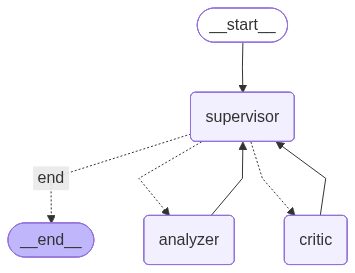

In [ ]:
app

### **(3) 추적 확인**

예제 코드를 통해 추적을 확인해 봅시다.


In [ ]:
# 추적 확인용
reviews = [
    "배송은 빨랐고 발림성도 좋았는데, 향은 너무 강해서 아쉬웠어요.",
    "보습은 오래가서 좋았는데 가격은 조금 비쌌어요.",
    "포장이 찌그러져 왔지만 향은 은은해서 마음에 들었어요.",
    "처음 발랐을 때는 촉촉했는데 시간이 지나니까 금방 건조해졌어요."
]

results = []

for review in reviews:
    initial_state = {
        "review": review,
        "analyzer_result": None,
        "critic_result": None,
        "retry_count": 0,
        "max_retries": 2,
        "next_agent": "analyzer"
    }

    result = app.invoke(initial_state)
    results.append(result)

results

[{'review': '배송은 빨랐고 발림성도 좋았는데, 향은 너무 강해서 아쉬웠어요.',
  'analyzer_result': {'items': [{'aspect': '향',
     'label': 0,
     'evidence': '향은 너무 강해서 아쉬웠어요'}]},
  'critic_result': {'verdict': '적합',
   'reason': "분석 결과가 리뷰 내용과 일치하며, 근거로 '향은 너무 강해서 아쉬웠어요'라는 명확한 문장이 제시되어 있음"},
  'retry_count': 0,
  'max_retries': 2,
  'next_agent': 'end'},
 {'review': '보습은 오래가서 좋았는데 가격은 조금 비쌌어요.',
  'analyzer_result': {'items': [{'aspect': '보습',
     'label': 1,
     'evidence': '보습은 오래가서 좋았는데'},
    {'aspect': '가격', 'label': 0, 'evidence': '가격은 조금 비쌌어요'}]},
  'critic_result': {'verdict': '적합',
   'reason': "각 항목에 대해 제시된 근거가 해당 측면의 평가를 명확하게 뒷받침하고 있음. '보습'에 대해서는 '보습은 오래가서 좋았는데'라는 긍정적인 근거가, '가격'에 대해서는 '가격은 조금 비쌌어요'라는 부정적인 근거가 적절하게 제시되어 있음."},
  'retry_count': 0,
  'max_retries': 2,
  'next_agent': 'end'},
 {'review': '포장이 찌그러져 왔지만 향은 은은해서 마음에 들었어요.',
  'analyzer_result': {'items': [{'aspect': '포장',
     'label': 0,
     'evidence': '포장이 찌그러져 왔지만'},
    {'aspect': '향', 'label': 1, 'evidence': '향은 은은해서 마음에 들었어요'}]}

#### Agent 실행 추적 시 평가

In [ ]:
ALLOWED_ASPECTS = {"보습", "가격", "향", "포장"}

def perform_eval(run):
    run = run or {}
    outputs = run.get("outputs") or {}

    # output이 final_state 안에 들어간 경우 대비
    if isinstance(outputs.get("final_state"), dict):
        outputs = outputs.get("final_state") or {}

    analyzer_result = outputs.get("analyzer_result") or {}
    critic_result = outputs.get("critic_result") or {}

    items = analyzer_result.get("items") or []

    invalid_aspects = []


    # analyzer_result의 aspect가 허용된 속성 목록 안에 있는지 평가
    for item in items:
        if not isinstance(item, dict):
            invalid_aspects.append("INVALID_ITEM")
            continue

        aspect = item.get("aspect")

        if aspect not in ALLOWED_ASPECTS:
            invalid_aspects.append(aspect)

    # 허용되지 않은 aspect가 있으면 0, 없으면 1
    aspect_scope_score = 1 if not invalid_aspects else 0


    # critic이 최종적으로 "적합" 판정을 냈는지 확인
    verdict = critic_result.get("verdict", "")
    # critic이 "적합"으로 판단하면 1, 아니면 0
    critic_verdict_score = 1 if verdict == "적합" else 0

    return {
        "aspect_scope_score": aspect_scope_score,
        "critic_verdict_score": critic_verdict_score
    }

## **3. 미션④ : Agent 고도화**

* [필수] Supervisor 중심 반복 제어
    - LLM 기반 흐름 제어
    - reason_code 기반 재시도 정책
* [필수] DB에 쌓인 리뷰 예측 batch 처리
* [선택항목] 다음은 예시 입니다.
    - 각 에이전트 고도화 : 성능/정확도를 높이기 위한 프롬프트 개선 등
    - HITL 노드 설계 : 특정 조건 시 Human Review 전환
    - 그 외 팀 내에서 추가 기능 검토 후 구현 가능


### **(1) Supervisor 중심 반복 제어**

* Supervisor Agent : 통제 정책 오케스트레이터(Policy Orchestrator)
    * Critic 판정이 ‘부적합’ 일 때 LLM은
        * critic_reason을 확인하여 reason_code 분류
        * 재시도 시 필요한 짧은 수정 지시를 repair_directive에 저장


#### **1) State 보완**

In [19]:
class ReviewState(TypedDict):
    # 입력 리뷰
    review: str

    # 개별 에이전트 실행 결과
    analyzer_result: Optional[Dict[str, Any]]   # {"items":[{"aspect":..., "label":..., "evidence":...}, ...]}
    critic_result: Optional[Dict[str, Any]]     # {"verdict":"적합|부적합", "reasons":"..."}

    # supervisor 판단 결과
    reason_code: Optional[Literal["OUTPUT_ERROR", "SCOPE_ERROR", "EVIDENCE_ERROR", "QUALITY_ERROR"]]
    repair_directive: Optional[str]

    # 흐름 제어
    retry_count: int
    max_retries: int
    next_agent: Optional[Literal["analyzer", "critic", "hitl", "end"]]

    # HITL 결과 (human in the loop)
    human_decision: Optional[Literal["APPROVE", "REVISE", "ABORT", "OVERRIDE"]]
    human_reason: Optional[str]

In [20]:
llm = ChatOpenAI(model="gpt-4.1-mini", temperature=0.2)

#### **2) Agent 노드 준비**

In [21]:
# 정책 및 필요 함수 준비 : 아래 내용을 수정해서 사용하세요.

REASON_CODES = {"OUTPUT_ERROR", "SCOPE_ERROR", "EVIDENCE_ERROR", "QUALITY_ERROR", "OK"}
RETRYABLE = {"OUTPUT_ERROR", "SCOPE_ERROR", "EVIDENCE_ERROR"}

REPAIR_TEMPLATES = {
    "OUTPUT_ERROR": "dict 1개만 출력. 코드블록/설명 없이 items 구조와 label(0/1)을 맞춰라.",
    "SCOPE_ERROR": "aspect는 보습, 가격, 향, 포장만 사용하라. 다른 표현은 가장 가까운 값으로 매핑하라.",
    "EVIDENCE_ERROR": "evidence는 리뷰 원문에 실제로 있는 연속된 문구만 사용하라.",
    "QUALITY_ERROR": "리뷰에 없는 내용을 만들지 말고, 애매하면 해당 aspect는 제외하라."
}

# 딕셔너리 파싱 함
def parse_dict(text, default):
    try:
        return ast.literal_eval(text)
    except:
        return default

* Analyzer Agents 보완

In [22]:
def analyzer_node(state: ReviewState):
    review = state.get('review')
    feedback = state.get("repair_directive") or ""

    sys_msg = '''
    # 역할 : 너는 상품 리뷰에서 주요 속성을 추출하고 감성을 분석하는 전문 데이터 분석가야.

    # 지침:
    - 리뷰에서 언급된 주요 속성을 파악하되, 명시적인 단어가 없더라도 문맥을 파악하여 반드시 아래의 [표준 속성 목록 및 분류 기준] 중 하나로 통일해서 출력해.
    - [표준 속성 목록 및 분류 기준]
      1) 보습: 수분감, 촉촉함, 시원함(쿨링감), 건조함 개선, 피부 진정 등
      2) 가격: 가성비, 저렴함, 비쌈, 세일, 용량 대비 가격 등
      3) 향: 냄새, 향기, 무향, 독함, 은은함 등
      4) 포장: 용량(대용량 등), 케이스, 디자인, 용기, 사이즈(크기), 펌프, 패키징 등
    - 각 속성에 대한 감성을 긍정은 1, 부정은 0으로 평가해.
    - 판정의 근거가 되는 리뷰 내의 구절을 원문 그대로 추출해.
    - 동일한 속성에 대해 긍정과 부정이 혼재되어 있을 경우, 대표 감성 딱 1개만 출력해. (중복 속성명 출력 금지)
    - "무난하다", "보통이다", "나쁘지 않다", "그럭저럭이다" 등 중립적이거나 미지근한 표현은 절대 추출 대상(items)에 포함하지 마라.
    - 아주 확실한 장점(1)이나 명확한 단점(0)이 드러나는 속성만 추출해라.
    - 추출된 결과가 2개 이상일 경우, items 배열 내의 객체 순서는 반드시 "보습", "가격", "향", "포장" 속성 순서대로 정렬해서 출력해라.

    # 제약사항:
    - 반드시 JSON 형식으로만 응답할 것.
    - 언급되지 않은 속성은 리스트에 포함하지 말 것.

    # 출력 JSON 형식:
    {
      "items": [
        {"aspect": "속성명", "label": 0 또는 1, "evidence": "근거문구"}
      ]
    }
    '''
    human_msg = f"# review:\n{review}\n\n# feedback:\n{feedback}"

    response = llm.invoke([SystemMessage(content=sys_msg), HumanMessage(content=human_msg)])

    try:
        content = response.content.strip()
        if content.startswith("```json"):
            content = content.replace("```json", "").replace("```", "").strip()
        parsed_result = json.loads(content)

        # 💡 파이썬을 이용해 무조건 원하는 순서대로 강제 정렬!
        sort_order = {"보습": 1, "가격": 2, "향": 3, "포장": 4}

        if "items" in parsed_result:
            # sort_order에 정의된 순서(1,2,3,4)를 기준으로 정렬. 모르는 속성은 맨 뒤(99)로 밀어냄.
            parsed_result["items"] = sorted(
                parsed_result["items"],
                key=lambda x: sort_order.get(x.get("aspect", ""), 99)
            )
    except Exception as e:
        print(f"JSON 파싱 에러: {e}")
        parsed_result = {"items": []}

    # 💡 수정 1: 불필요한 messages 제거 및 critic_result 초기화
    return {
        "analyzer_result": parsed_result,
        "critic_result": None
    }

* Critic Agent 보완

In [23]:
# ---------------- Critic Node ----------------
def critic_node(state: ReviewState):
    analyzer_result = state.get("analyzer_result", {})
    review = state.get("review", "") # 💡 리뷰 원문 가져오기
    sys_msg = '''
[역할]
당신은 리뷰 분석 검증 전문가입니다.

[지침]
리뷰와 분석 결과를 비교하여 검토하세요.

다음을 확인하세요:
1. 리뷰에 존재하는 aspect가 누락되지 않았는가
2. label(긍정/부정)이 적절한가
3. evidence가 실제 리뷰 내용과 일치하는가

[판단]
반드시 verdict는 아래 둘 중 하나만 사용하세요.
- Conformity
- Non-conformity

[출력 형식]
{
    "verdict": "Conformity",
    "reason": "분석 결과가 리뷰와 일치함"
}
'''
    # 💡 리뷰 원문과 분석 결과를 함께 전달!
    human_msg = f"# Review (원문):\n{review}\n\n# Result (분석결과):\n{json.dumps(analyzer_result, ensure_ascii=False)}"

    response = llm.invoke([SystemMessage(content=sys_msg), HumanMessage(content=human_msg)])

    try:
        content = response.content.strip()
        if content.startswith("```json"):
            content = content.replace("```json", "").replace("```", "").strip()
        parsed_result = json.loads(content)

    except Exception as e:
        print(f"JSON 파싱 에러: {e}")
        parsed_result = {"verdict": "Non-conformity", "reason": "포맷 에러"}

     # 💡 messages는 삭제
    return {
        "critic_result": parsed_result
    }

In [24]:
def hitl_node(state: ReviewState):
    print("\n" + "="*40)
    print(" [HITL 개입 필요] 최대 재시도 횟수를 초과했습니다")
    print(f" 현재 추출된 결과: {json.dumps(state.get('analyzer_result'), ensure_ascii=False)}")
    print("="*40)

    print("\n[옵션]")
    print("1. 'y' 또는 엔터 : 현재 결과 승인 (APPROVE) -> DB 저장 및 종료")
    print("2. 'n' 또는 'exit' : 결과 폐기 (ABORT) -> 저장 없이 종료")
    print("3. 'o' 또는 'edit' : 직접 결과 수정 (OVERRIDE) -> 직접 데이터 입력 후 종료")
    print("4. 텍스트 입력 : 수정 지시 (REVISE) -> 해당 내용으로 재분석")

    user_input = input("결정을 입력하세요: ").strip()

    # 1. 승인 (APPROVE)
    if user_input.lower() in ['', '1', 'y', 'yes', 'approve']:
        return {
            "human_decision": "APPROVE",
            "human_reason": "Looks good enough",
            "next_agent": "end"
        }

    # 2. 폐기 (ABORT)
    elif user_input.lower() in ['2', 'n', 'exit', 'quit', 'no', 'abort']:
        return {
            "human_decision": "ABORT",
            "human_reason": "Too flawed to save",
            "next_agent": "end"
        }

    # 3. 직접 수정 (OVERRIDE)
    elif user_input.lower() in ['3', 'o', 'edit', 'override']:
        print("\n[직접 수정 모드] 새로운 분석 결과를 직접 입력합니다.")
        new_items = []
        allowed_aspects = ["보습", "가격", "향", "포장"]

        while True:
            # 1. 속성 입력 (콤마로 구분)
            aspects_input = input("\n▶ 속성을 입력하세요 (예: 보습, 향) [허용: 보습, 가격, 향, 포장] (취소/종료: 엔터): ").strip()
            if not aspects_input:
                break

            # 쉼표 기준으로 나누고 양옆 공백 제거
            aspects = [a.strip() for a in aspects_input.split(",")]

            # 허용되지 않은 속성이 있는지 검사
            invalid_aspects = [a for a in aspects if a not in allowed_aspects]
            if invalid_aspects:
                print(f"경고: 잘못된 속성이 포함되어 있습니다 -> {', '.join(invalid_aspects)}")
                print("'보습', '가격', '향', '포장' 중에서만 입력해주세요.")
                continue # 다시 속성 입력으로 돌아감

            # 2. 라벨 입력 (콤마로 구분)
            while True:
                labels_input = input(f"▶ 위 속성({', '.join(aspects)})에 맞는 라벨을 순서대로 입력하세요 (예: 1, 0): ").strip()
                labels = [l.strip() for l in labels_input.split(",")]

                # 개수 검증
                if len(labels) != len(aspects):
                    print(f"경고: 입력한 속성의 개수({len(aspects)}개)와 라벨의 개수({len(labels)}개)가 다릅니다.")
                    continue

                # 0 또는 1 검증
                valid_labels = True
                parsed_labels = []
                for l in labels:
                    if l not in ['0', '1']:
                        print(f"경고: 라벨은 0 또는 1만 입력 가능합니다. (잘못된 입력: '{l}')")
                        valid_labels = False
                        break
                    parsed_labels.append(int(l))

                if valid_labels:
                    break # 라벨 입력 성공, 반복문 탈출

            # 3. 근거 문구 입력 (문장 안에 쉼표가 있을 수 있으므로 하나씩 개별 입력)
            print("▶ 각 속성에 대한 근거 문구를 입력하세요:")
            evidences = []
            for aspect in aspects:
                ev = input(f"  - '{aspect}'의 근거: ").strip()
                evidences.append(ev)

            # 4. 검증 완료된 데이터 조합하여 저장
            for i in range(len(aspects)):
                new_items.append({
                    "aspect": aspects[i],
                    "label": parsed_labels[i],
                    "evidence": evidences[i]
                })

            more = input("\n항목을 더 추가하시겠습니까? (y/n): ").strip().lower()
            if more != 'y':
                break

        return {
            "analyzer_result": {"items": new_items},
            "human_decision": "OVERRIDE",
            "human_reason": "Human manually inputted values",
            "next_agent": "end",
            "reason_code": None,
            "repair_directive": None
        }

    # 4. 재수정 지시 (REVISE)
    else:
        return {
            "human_decision": "REVISE",
            "human_reason": user_input,
            "repair_directive": f"[Human Feedback] {user_input}", # Analyzer에게 전달
            "retry_count": 0, # 재시도 카운트 초기화
            "next_agent": "analyzer"
        }

* Supervisor Agent 보완

In [25]:
# ---------------- Supervisor Node ----------------
def supervisor_node(state: ReviewState):
    critic_result = state.get("critic_result")
    verdict = (critic_result or {}).get("verdict", "")
    critic_reason = (critic_result or {}).get("reason", "")

    retry_count = state["retry_count"]
    max_retries = state["max_retries"]

    # 1. analyzer 아직 안 돌았음
    if not state["analyzer_result"]:
        return {
            "next_agent": "analyzer"
        }

    # 2. critic 아직 안 돌았음
    if not critic_result:
        return {
            "next_agent": "critic"
        }

    # 3. Critic 결과가 적합이면 종료
    if verdict == "Conformity":
        return {
            "human_decision": "APPROVE",    # 자동 통과 기록 (추적용)
            "next_agent": "end",            # 바로 DB 저장(또는 종료) 노드로 이동
            "reason_code": None,            # 이전 턴에서 남아있던 에러 기록 삭제
            "repair_directive": None        # 이전 턴에서 남아있던 에러 기록 삭제
        }

    # 4. Critic 결과가 부적합인데 재시도 초과면 종료
    if retry_count >= max_retries:
        return {
            "reason_code": "QUALITY_ERROR",
            "next_agent": "hitl"
        }

    # 5. Critic 결과가 부적합이면 reason_code / repair_directive 생성
    sys_msg = """
[역할]
당신은 상품 리뷰 분석 Agent 시스템의 Supervisor Agent입니다.
당신의 역할은 Critic의 부적합 사유를 분석하여 오류 유형(reason_code)을 분류하고,
Analyzer가 다음 재분석에서 참고할 짧은 수정 지시(repair_directive)를 작성하는 것입니다.

[reason_code 종류]
1. OUTPUT_ERROR
- 의미: 출력 형식 또는 스키마 오류
- 예: JSON 파싱 실패, items 구조 오류, label 값 범위 오류

2. SCOPE_ERROR
- 의미: 허용 범위 밖의 aspect 사용
- 예: 보습/가격/향/포장 외 속성 생성, 동의어 처리 실패

3. EVIDENCE_ERROR
- 의미: evidence 품질 문제
- 예: evidence가 리뷰 원문과 불일치, 요약 형태, 근거 없음

4. QUALITY_ERROR
- 의미: 분석 품질 문제
- 예: 환각, 감성 판단 모호, 반복해도 개선 어려운 오류

[Routing 정책]
- OUTPUT_ERROR: RETRY
- SCOPE_ERROR: RETRY
- EVIDENCE_ERROR: RETRY
- QUALITY_ERROR: END

[출력 규칙]
반드시 JSON 형식으로만 답변하세요.
reason_code는 반드시 위 4개 중 하나만 사용하세요.
routing은 반드시 RETRY 또는 END 중 하나만 사용하세요.
repair_directive는 Analyzer가 바로 참고할 수 있도록 짧고 구체적으로 작성하세요.

[출력 형식]
{
  "reason_code": "SCOPE_ERROR",
  "routing": "RETRY",
  "repair_directive": "aspect는 보습, 가격, 향, 포장 중 하나만 사용하세요. 다른 표현은 가장 가까운 aspect로 매핑하세요."
}
"""

    human_msg = f"""
[Critic 부적합 사유]
{critic_reason}

[현재 분석 결과]
{state.get("analyzer_result")}
"""

    response = llm.invoke([SystemMessage(content=sys_msg), HumanMessage(content=human_msg)])

    policy_result = json.loads(response.content)

    reason_code = policy_result.get("reason_code", "QUALITY_ERROR")
    routing = policy_result.get("routing", "END")
    repair_directive = policy_result.get("repair_directive", "")

    # 안전장치
    if reason_code not in ["OUTPUT_ERROR", "SCOPE_ERROR", "EVIDENCE_ERROR", "QUALITY_ERROR"]:
        reason_code = "QUALITY_ERROR"

    if routing not in ["RETRY", "END"]:
        routing = "END"

    # HITL 조건 2: QUALITY_ERROR(AI가 스스로 해결 불가능하다고 판단) 시 즉시 사람 호출
    if routing == "END":
        return {
            "reason_code": reason_code,
            #"repair_directive": repair_directive,
            "next_agent": "hitl"       # 바로 종료(end)하지 않고 사람에게 넘김
        }

    # RETRY 판단이면 analyzer 재실행
    return {
        "reason_code": reason_code,
        "repair_directive": repair_directive,
        "next_agent": "analyzer",
        "retry_count": retry_count + 1
    }


* route_next 함수

In [26]:
# ---------------- 라우팅 함수 ----------------
def route_next(state: ReviewState):
    return state["next_agent"]

* 그래프

In [27]:
workflow = StateGraph(ReviewState)
workflow.add_node("supervisor", supervisor_node)
workflow.add_node("analyzer", analyzer_node)
workflow.add_node("critic", critic_node)
workflow.add_node("hitl", hitl_node)
workflow.add_edge(START, "supervisor")
workflow.add_conditional_edges("supervisor", route_next,
    {"analyzer": "analyzer", "critic": "critic", "hitl": "hitl",
     "end": END  }
)
# Analyzer와 Critic 작업이 끝나면 항상 Supervisor로 복귀
workflow.add_edge("analyzer", "supervisor")
workflow.add_edge("critic", "supervisor")
# HITL 노드에서 사용자 선택(REVISE 또는 APPROVE/ABORT)에 따른 갈림길 추가
workflow.add_conditional_edges(
    "hitl", route_next,
    {
        "analyzer": "analyzer", # REVISE를 선택해 next_agent가 analyzer가 된 경우
        "end": END              # APPROVE나 ABORT를 선택해 next_agent가 end가 된 경우
    }
)
app = workflow.compile()

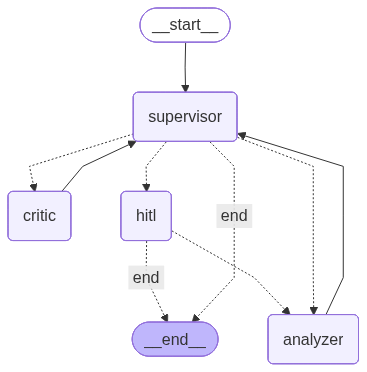

In [28]:
app

* 실행 테스트

In [29]:
# 실행흐름 (trace) 확인
import json

review = '''
배송이 하루 만에 와서 진짜 최고네요! 포장도 안 뜯고 그냥 둡니다.
제품은 그냥 무난해요. 딱히 좋은 점도 나쁜 점도 없는 보통 화장품입니다.
그럭저럭 나쁘지 않네요. 재구매 의사는 없습니다.
'''
# review = '''너무 마음에 듭니다. 추쳔해요. 30ml는 용량에 비해 너무 비싸서 구매하기 부담스러웠는데 세일기간에 저렴하게 잘 산 것 같습니다. 향은 여성스럽고 너무 이쁜 향이네요. 근데 향을 계속 맡다보면 머리가 아파요
# '''

print("=== [1] 에이전트 실행 시작 (스트리밍 모드) ===")
initial_state = {
    "review": review,
    "analyzer_result": None, # Add this line
    "critic_result": None,   # Add this line
    "retry_count": 0,
    "max_retries": 2,
    "next_agent": None       # Add this line
}

# 변수를 하나 만들어 최종 상태를 저장할 준비
final_state = initial_state.copy()

# app.invoke() 대신 app.stream()을 사용하여 루프를 돎
for output in app.stream(initial_state):
    # output은 {"노드명": {업데이트된 상태값}} 형태의 딕셔너리
    for node_name, state_update in output.items():
        print(f"\n▶️ [실행 완료 노드: {node_name}]")
        # 해당 노드에서 무엇이 업데이트되었는지 출력
        print(json.dumps(state_update, indent=2, ensure_ascii=False))

        # 스트리밍이 진행되면서 final_state를 계속 업데이트
        final_state.update(state_update)

print("\n===== 에이전트 루프 실행 완료 =====")

# 핵심 결과만 따로 빼서 확인
analyzer_result = final_state.get("analyzer_result", {})
print("\n[추출된 핵심 분석 결과]")
print(json.dumps(analyzer_result, indent=2, ensure_ascii=False))

# review = '''잘 사용하고 있어요. 보습력도 좋고 향도 좋아서 잘 사용합니다. 용량도 커서 부담없이 자주 바르고 있어요. 앞으로도 잘 사용할 것 같아요. 보습력 향 모두 만족하는 상품입니다.
# '''

# # Agent 실행
# print("=== [1] 에이전트 실행 시작 ===")
# initial_state = {
#     "review": review,
#     "retry_count": 0,
#     "max_retries": 2
# }

# # workflow를 invoke하여 실행
# final_state = app.invoke(initial_state)
# print("\n에이전트 실행 완료!")

# # 결과 출력
# print("\n=== 에이전트 최종 상태 ===")

# # 딕셔너리를 보기 좋게 출력하기 위해 json.dumps 사용
# print(json.dumps(final_state, indent=2, ensure_ascii=False))

# # 핵심 결과만 따로 빼서 확인
# analyzer_result = final_state.get("analyzer_result", {})
# print("\n[추출된 핵심 분석 결과]")
# print(json.dumps(analyzer_result, indent=2, ensure_ascii=False))


=== [1] 에이전트 실행 시작 (스트리밍 모드) ===

▶️ [실행 완료 노드: supervisor]
{
  "next_agent": "analyzer"
}

▶️ [실행 완료 노드: analyzer]
{
  "analyzer_result": {
    "items": []
  },
  "critic_result": null
}

▶️ [실행 완료 노드: supervisor]
{
  "next_agent": "critic"
}

▶️ [실행 완료 노드: critic]
{
  "critic_result": {
    "verdict": "Non-conformity",
    "reason": "리뷰에는 배송, 포장, 제품 품질, 재구매 의사 등 여러 aspect가 언급되었으나 분석 결과에 아무 aspect도 포함되어 있지 않아 누락되었음."
  }
}

▶️ [실행 완료 노드: supervisor]
{
  "reason_code": "OUTPUT_ERROR",
  "repair_directive": "items 배열이 비어있지 않도록 리뷰에서 언급된 허용된 aspect(보습, 가격, 향, 포장) 중 하나 이상을 반드시 포함하세요.",
  "next_agent": "analyzer",
  "retry_count": 1
}

▶️ [실행 완료 노드: analyzer]
{
  "analyzer_result": {
    "items": [
      {
        "aspect": "포장",
        "label": 1,
        "evidence": "포장도 안 뜯고 그냥 둡니다."
      }
    ]
  },
  "critic_result": null
}

▶️ [실행 완료 노드: supervisor]
{
  "next_agent": "critic"
}

▶️ [실행 완료 노드: critic]
{
  "critic_result": {
    "verdict": "Non-conformity",
    "reason": "리뷰에는 '배송'과 

### **(2) DB에 쌓인 리뷰 예측 batch 처리**

* 리뷰 데이터 여러 건을 임의로 생성하여 Step1에서 생성한 DB의 테이블에 저장.
* DB에서 분석 대상 리뷰 조회(예: agent_aspect가 NULL인 데이터)
* 각 리뷰에 대해 Agent 실행
* 분석 결과(items)에서 aspect , label 추출
* DB에 결과 저장 (UPDATE)


#### **1) 데이터 준비**
* data.csv 파일 로딩
* review 칼럼의 값만 DB에 저장

In [30]:
# 코랩에 파일 업로드
from google.colab import files
uploaded = files.upload()

Saving data.csv to data.csv


In [31]:
df = pd.read_csv('/content/data.csv') # 코랩에 파일 업로드로 한경우
#df = pd.read_csv(path+'data.csv') # 코랩말고 구글 드라이브에 있는걸로 할거면 이걸로 실행

In [32]:
reviews = df['review']
reviews.tail()

,review
195,피부 좋은 직장후배의 추천으로 알게 된 OO OOO 크림팩!!! 이제품을 쓰고 나의...
196,향수 필요해서 찾아 보다가 이 제품 할인 해서 구매하게 되었는데 품질이 생각보다 좋...
197,시원하다길래 반신반의하면서 구매했어요 엄청 시원한건아니지만 그래도 시원한감은 있어요...
198,꾸준히 애용하고 있습니다. 사용기한도 넉넉합니다. 특히 향이 은은하여 좋네요. 보습...
199,OO 자음 2종 기획 세트로 구매하면 구성품으로 여행용 작은 세트 4개가 들어있네요...


In [33]:
print(f"저장할 데이터 개수: {len(df)}")

저장할 데이터 개수: 200


In [34]:
#혹시 db없으면 주석 풀고 실행
DB_PATH = "/content/drive/MyDrive/proj2_agent/reviews.db"
# DB 및 테이블 생성 함수
def init_db():
  conn = sqlite3.connect(DB_PATH)
  cursor = conn.cursor()
  cursor.execute("""
  CREATE TABLE IF NOT EXISTS reviews (
      id INTEGER PRIMARY KEY AUTOINCREMENT,
      review TEXT,
      agent_aspect TEXT,
      agent_label TEXT,
      updated_at DEFAULT (DATETIME('now', 'localtime'))
  )
  """)
  conn.commit()
  conn.close()

# if 'db_initialized' not in st.session_state:
#     init_db()
#     st.session_state['db_initialized'] = True

init_db()

In [35]:
DB_PATH = "/content/drive/MyDrive/proj2_agent/reviews.db"

conn = sqlite3.connect(DB_PATH)
cursor = conn.cursor()

for review_text in df['review']:
    cursor.execute("INSERT INTO reviews (review) VALUES (?)", (review_text,))

conn.commit()
conn.close()

#### **2) 리뷰를 읽어서 Agent 실행후 결과 저장**

In [44]:
# 함수 생성

# 1) 미처리 리뷰 조회 함수
def unprocessed_review():
  conn = sqlite3.connect(DB_PATH)
  cursor = conn.cursor()

  cursor.execute("SELECT id, review FROM reviews WHERE agent_aspect IS NULL")
  null_aspect = cursor.fetchall()

  unprocessed_reviews = [
        {"id": row[0], "review": row[1]}
        for row in null_aspect
    ]

  conn.close()

  return unprocessed_reviews

# 2) Agent 결과에서 aspect, label 추출 함수


# 3) DB 업데이트
# agent 실행 후, 결과 DB 저장 함수
def save_analyze(pk_id:int, result: dict):
  conn = sqlite3.connect(DB_PATH)
  cursor = conn.cursor()

  # analyzer_result에서 aspect, label 추출
  items = result.get("analyzer_result", {}).get("items", [])
  aspects = [item["aspect"] for item in items]
  labels = [item["label"] for item in items]
  # INSERT
  aspects_json = json.dumps(aspects, ensure_ascii=False)
  labels_json = json.dumps(labels)

  # UPDATE 실행
  cursor.execute(
    "UPDATE reviews SET agent_aspect = ?, agent_label = ? WHERE id = ?",
    (aspects_json, labels_json, pk_id)
  )
  conn.commit()
  conn.close()


# 4) batch 실행
def batch(unprocessed_reviews: list[Dict[str, Any]]):
  count = 0;
  for row in unprocessed_reviews:
    pk_id = row['id']
    review_msg = row['review']
    state_data: ReviewState = {
        "review": review_msg,
        "analyzer_result": None,
        "critic_result": None,
        "reason_code": None,
        "repair_directive": None,
        "retry_count": 0,
        "max_retries": 2,
        "next_agent": None,
        "human_decision": None,
        "human_reason": None
    }
    result = app.invoke(state_data)
    save_analyze(pk_id, result)
    count +=1
    print("실행 중 :", count )


In [47]:
# 배치 실행
unprocessed_reviews = unprocessed_review()
batch(unprocessed_reviews)
# 실행 결과 확인



KeyboardInterrupt: 

In [38]:
import json
#리뷰 분석 결과 집계

def review_analyze_result():
  conn = sqlite3.connect(DB_PATH)
  cursor = conn.cursor()

  cursor.execute("SELECT agent_aspect,agent_label  FROM reviews ")
  rows = cursor.fetchall()

  conn.close()

  result = {}

  for row in rows:
    if row[0] and row[1]:
      aspects = json.loads(row[0])
      labels = json.loads(row[1])

      for aspect, label in zip(aspects, labels):
        if aspect not in result:
          result[aspect] = {1: 0, 0: 0}

        if label in [1, 0]:
          result[aspect][label] += 1


  return result

# 결과
# {'보습': {1: 82, 0: 26}, '향': {1: 57, 0: 19}, '가격': {1: 52, 0: 29}, '포장': {1: 16, 0: 7}}

In [39]:
result = review_analyze_result()
print(result)

{'[': {1: 0, 0: 0}, '"': {1: 0, 0: 0}, '보': {1: 0, 0: 0}, '습': {1: 0, 0: 0}, ',': {1: 0, 0: 0}, ' ': {1: 0, 0: 0}, '향': {1: 38, 0: 12}, '보습': {1: 53, 0: 10}, '가격': {1: 26, 0: 17}, '포장': {1: 13, 0: 8}}


In [51]:
# 리뷰 분석 결과 건별 조회

# 조회할 id 선택
def select_id():
  conn = sqlite3.connect(DB_PATH)
  cursor = conn.cursor()

  cursor.execute("SELECT id FROM reviews ")
  rows = cursor.fetchall()

  conn.close()

  ids = [row[0] for row in rows]

  return ids

# 원문, 시각, 결과
def id_to_data(pk_id: int):
    try:
        pk_id = int(pk_id)
    except (TypeError, ValueError):
        # 방어 1: 에러가 나도 두 번째 값은 무조건 리스트 [] 로 통일
        return None, [], None, "리뷰 ID는 숫자로 입력해야 합니다."

    conn = sqlite3.connect(DB_PATH)
    cursor = conn.cursor()
    cursor.execute("SELECT * FROM reviews WHERE id = ?", (pk_id,))
    row = cursor.fetchone()
    conn.close()

    if row is None:
        return None, [], None, f"ID {pk_id}에 해당하는 리뷰가 없습니다."

    review = row[1]
    raw_aspect = row[2]
    raw_label = row[3]
    updated_at = row[4]

    # 상태 구분을 위해 None인지 확인하지만, 반환할 때는 안전하게 []를 줌
    if raw_aspect is None or raw_label is None:
        return review, [], updated_at, "미처리"

    aspects = json.loads(raw_aspect)
    labels = json.loads(raw_label)

    if not aspects or not labels:
        return review, [], updated_at, "빈결과"

    aspect_label = []
    for aspect, label in zip(aspects, labels):
        if label == 1:
            status = "긍정"
        elif label == 0:
            status = "부정"
        else:
            status = "알 수 없음"
        aspect_label.append(f"{aspect}: {status}")

    return review, aspect_label, updated_at, "조회 성공"

def id_to_review(pk_id:int):
  conn = sqlite3.connect(DB_PATH)
  cursor = conn.cursor()

  cursor.execute("SELECT review FROM reviews WHERE id = ?", (pk_id,))
  review = cursor.fetchone()[0]

  conn.close()

  return review


In [52]:
ids = select_id()

print(ids)

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 219, 220, 221, 22

In [54]:
review, aspect_label, updated_at, stat = id_to_data(36)
print(review)
print(aspect_label)
print(updated_at)
print(stat)

홈쇼핑 광고에서도 정말 많이 하고 많은 분들이 궁금해하셨던 바로 그 제품 사용 후기 가져왔습니다. 저도 구매를 직접 해서 써 봤는데 좋은 점이 없는 것 같아서 알려드리고 싶었어요... 단점이 너무 많은 제품이라.. 무슨 말부터 시작을 해야 될 지 모르겠습니다. 일단 이 제품을 사게 된 계기는 홈쇼핑 광고를 보고 샀어요. 구성이 너무 좋아서 구매를 했습니다. 배송은 빨리 왔고 오자 마자 기대를 가지고 사용하게 되었어요. 하지만 하는 내내 풍기는 이상한 냄새에 머리가 아팠습니다. 두피에 자극도 있어서 지금 너무 가려운 것 같습니다...ㅠㅠ 약을 먹어도 가려움이 없어지지 않네요. 염색제 색상도 마음에 들지 않았고 발색도 너무 어둡게 나온 것 같습니다. 결론은 저는 추천하고 싶지 않은 제품이네요~ 다른 염색약 사용하시는 것이 더 좋을 것 같다는 게 제 결론입니다..!!
['향: 부정']
2026-05-12 02:42:16
조회 성공


In [43]:
reviewd = id_to_review(36)
print(reviewd)

홈쇼핑 광고에서도 정말 많이 하고 많은 분들이 궁금해하셨던 바로 그 제품 사용 후기 가져왔습니다. 저도 구매를 직접 해서 써 봤는데 좋은 점이 없는 것 같아서 알려드리고 싶었어요... 단점이 너무 많은 제품이라.. 무슨 말부터 시작을 해야 될 지 모르겠습니다. 일단 이 제품을 사게 된 계기는 홈쇼핑 광고를 보고 샀어요. 구성이 너무 좋아서 구매를 했습니다. 배송은 빨리 왔고 오자 마자 기대를 가지고 사용하게 되었어요. 하지만 하는 내내 풍기는 이상한 냄새에 머리가 아팠습니다. 두피에 자극도 있어서 지금 너무 가려운 것 같습니다...ㅠㅠ 약을 먹어도 가려움이 없어지지 않네요. 염색제 색상도 마음에 들지 않았고 발색도 너무 어둡게 나온 것 같습니다. 결론은 저는 추천하고 싶지 않은 제품이네요~ 다른 염색약 사용하시는 것이 더 좋을 것 같다는 게 제 결론입니다..!!


## **4. 미션⑤ : 대시보드 만들기**

### (1) 한글 폰트 준비

* 한글폰트 설치

In [ ]:
!apt-get -y install fonts-nanum

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 3 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 1s (8,341 kB/s)
Selecting previously unselected package fonts-nanum.
(Reading database ... 118252 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...


* 세션 다시시작

### Insight Report Agent 코드셀



In [11]:
%%writefile insight_report_agent.py
import json
import os
import re
from html import escape
from io import BytesIO
from typing import Any, Dict, List, Literal, TypedDict

from langchain_core.messages import HumanMessage, SystemMessage
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, START, END


# ==================================================
# LangSmith 설정
# ==================================================
# app.py와 동일한 프로젝트로 trace가 묶이도록 설정합니다.
os.environ.setdefault("LANGSMITH_TRACING", "true")
os.environ.setdefault("LANGSMITH_PROJECT", "proj2_agent")
os.environ.setdefault("LANGSMITH_ENDPOINT", "https://api.smith.langchain.com")


class InsightReportState(TypedDict, total=False):
    """Streamlit 대시보드에서 호출하는 리포트 생성 Agent State."""
    report_input: Dict[str, Any]
    report: Dict[str, Any]
    critic_result: Dict[str, Any]
    retry_count: int
    max_retries: int
    repair_directive: str
    next_agent: str
    error_log: str


REPORT_RETRYABLE = {"OUTPUT_ERROR", "NUMERIC_ERROR", "ACTION_ERROR"}


def _safe_json_loads(text: str) -> Dict[str, Any]:
    """LLM 응답에서 JSON 객체만 복원합니다."""
    text = str(text).strip()
    try:
        return json.loads(text)
    except Exception:
        start = text.find("{")
        end = text.rfind("}")
        if start >= 0 and end >= start:
            return json.loads(text[start:end + 1])
        raise


def build_fallback_report(report_input: Dict[str, Any], error_msg: str = "") -> Dict[str, Any]:
    """LLM 호출 실패 시 UI가 깨지지 않도록 최소 리포트를 생성합니다."""
    priority = report_input.get("priority_aspects", []) or []
    worst = priority[0].get("aspect", "확인 필요") if priority else "확인 필요"
    neg_rate = report_input.get("overall_negative_ratio", 0)

    return {
        "title": "상품 리뷰 감성 분석 요약 리포트",
        "summary_report": (
            f"총 {report_input.get('total_reviews', 0)}건의 리뷰와 "
            f"{report_input.get('total_aspect_mentions', 0)}건의 속성 판단 결과를 기준으로 분석했습니다. "
            f"전체 부정 비율은 {neg_rate}%이며, 개선 우선순위가 가장 높은 속성은 '{worst}'입니다. "
            "아래 개선안은 계산된 속성별 긍정/부정 수치를 기준으로 생성된 대체 리포트입니다."
        ),
        "key_findings": [
            f"개선 우선순위 1순위 속성은 '{worst}'입니다.",
            "부정 비율이 높은 속성은 상품 상세페이지, CS 안내, 제품 개선 항목으로 분리해 관리할 필요가 있습니다.",
            "긍정 비율이 높은 속성은 구매 설득 포인트로 유지하는 것이 좋습니다."
        ],
        "recommendations": [
            f"'{worst}'의 부정 비율을 낮추기 위한 상품/안내 문구 개선 항목을 우선 점검하세요.",
            "속성별 부정 비율 TOP 3를 기준으로 개선 우선순위를 정하고 담당 부서를 연결하세요.",
            "긍정 비율이 높은 속성은 상세페이지와 광고 문구에서 강점으로 강조하세요."
        ],
        "risk_notes": ["LLM 리포트 또는 Critic 단계 실패로 대체 리포트를 표시했습니다.", error_msg][:2],
    }


def _validate_report_shape(report: Dict[str, Any]) -> bool:
    required = ["title", "summary_report", "key_findings", "recommendations", "risk_notes"]
    if not all(k in report for k in required):
        return False
    if not isinstance(report.get("recommendations"), list):
        return False
    return len(report.get("recommendations", [])) == 3


def report_writer_node(state: InsightReportState) -> InsightReportState:
    """계산된 속성별 통계만 받아 현업용 리포트와 개선안 3가지를 작성합니다."""
    report_input = state.get("report_input", {})
    repair_directive = state.get("repair_directive", "")

    system_prompt = """
# 역할
너는 이커머스 상품 리뷰 분석 리포트를 작성하는 CX/상품기획 분석가다.

# 입력 데이터
리뷰 원문이 아니라 DB에서 집계한 속성별 긍정/부정 수치만 제공된다.

# 작성 규칙
- 숫자 계산을 새로 하지 말고, 입력된 통계값만 사용한다.
- 리뷰 원문 표현이나 구체 사례를 지어내지 않는다.
- 개선 제안은 반드시 3개만 작성한다.
- 개선 제안은 실행 가능한 문장으로 작성한다.
- 부정 비율과 부정 건수가 높은 속성을 개선 우선순위로 판단한다.
- 긍정 비율이 높은 속성은 유지/강화 포인트로 언급한다.
- Streamlit 대시보드에 바로 표시될 수 있게 간결하게 작성한다.

# 출력 형식
반드시 JSON 하나만 출력한다.
{
  "title": "리포트 제목",
  "summary_report": "5~7문장 요약 리포트",
  "key_findings": ["핵심 발견 1", "핵심 발견 2", "핵심 발견 3"],
  "recommendations": ["개선 제안 1", "개선 제안 2", "개선 제안 3"],
  "risk_notes": ["주의사항 또는 데이터 한계"]
}
""".strip()

    human_prompt = f"""
[속성별 감성 통계]
{json.dumps(report_input, ensure_ascii=False, indent=2)}

[수정 지시]
{repair_directive if repair_directive else "없음"}
""".strip()

    try:
        llm = ChatOpenAI(model=os.getenv("REPORT_AGENT_MODEL", "gpt-4.1-mini"), temperature=0.2)
        response = llm.invoke([SystemMessage(content=system_prompt), HumanMessage(content=human_prompt)])
        report = _safe_json_loads(response.content)
        return {"report": report}
    except Exception as e:
        return {"report": build_fallback_report(report_input, str(e)), "error_log": str(e)}


def report_critic_node(state: InsightReportState) -> InsightReportState:
    """완성된 리포트가 실제 수치와 어긋나지 않는지 Critic LLM으로 검수합니다."""
    report_input = state.get("report_input", {})
    report = state.get("report", {})

    if not _validate_report_shape(report):
        return {
            "critic_result": {
                "verdict": "REVISE",
                "reason_code": "OUTPUT_ERROR",
                "feedback": "리포트 JSON 형식이 요구사항과 다릅니다. recommendations는 반드시 3개여야 합니다.",
            }
        }

    system_prompt = """
# 역할
너는 상품 리뷰 리포트 검수 Critic이다.

# 검수 기준
1. 리포트가 입력 통계와 충돌하지 않는가?
2. 입력에 없는 리뷰 원문 사례나 표현을 지어내지 않았는가?
3. 개선 제안이 정확히 3개인가?
4. 개선 제안이 실무적으로 실행 가능한가?
5. 부정 비율/부정 건수가 높은 속성을 개선 우선순위로 다루는가?

# reason_code
- OK: 통과
- OUTPUT_ERROR: JSON 형식, 필수 키, 개선안 개수 문제
- NUMERIC_ERROR: 실제 수치와 리포트 내용 충돌
- ACTION_ERROR: 개선안이 모호하거나 실행 가능하지 않음
- QUALITY_ERROR: 큰 오류는 없지만 보고서 품질이 낮음

# 출력 형식
반드시 JSON 하나만 출력한다.
{
  "verdict": "APPROVED 또는 REVISE",
  "reason_code": "OK 또는 OUTPUT_ERROR 또는 NUMERIC_ERROR 또는 ACTION_ERROR 또는 QUALITY_ERROR",
  "feedback": "짧은 검수 의견",
  "repair_directive": "재작성 시 반영할 수정 지시. 통과면 빈 문자열"
}
""".strip()

    human_prompt = f"""
[입력 통계]
{json.dumps(report_input, ensure_ascii=False, indent=2)}

[작성된 리포트]
{json.dumps(report, ensure_ascii=False, indent=2)}
""".strip()

    try:
        llm = ChatOpenAI(model=os.getenv("REPORT_CRITIC_MODEL", os.getenv("REPORT_AGENT_MODEL", "gpt-4.1-mini")), temperature=0)
        response = llm.invoke([SystemMessage(content=system_prompt), HumanMessage(content=human_prompt)])
        critic_result = _safe_json_loads(response.content)
    except Exception as e:
        critic_result = {
            "verdict": "APPROVED",
            "reason_code": "OK",
            "feedback": "Critic LLM 호출 실패. 리포트 형식 검증은 통과했으므로 화면 표시를 진행합니다.",
            "repair_directive": "",
            "critic_error": str(e),
        }
    return {"critic_result": critic_result}


def report_supervisor_node(state: InsightReportState) -> InsightReportState:
    """Report Agent 흐름을 제어하는 Supervisor."""
    report = state.get("report")
    critic = state.get("critic_result")
    retry_count = state.get("retry_count", 0)
    max_retries = state.get("max_retries", 1)

    if not report:
        return {"next_agent": "writer"}

    if not critic:
        return {"next_agent": "critic"}

    verdict = critic.get("verdict", "")
    reason_code = critic.get("reason_code", "")

    if verdict == "APPROVED" or reason_code == "OK":
        return {"next_agent": "end"}

    if reason_code in REPORT_RETRYABLE and retry_count < max_retries:
        return {
            "next_agent": "writer",
            "retry_count": retry_count + 1,
            "repair_directive": critic.get("repair_directive") or critic.get("feedback", ""),
            "critic_result": None,
        }

    return {"next_agent": "end"}


def route_report_next(state: InsightReportState) -> str:
    return state.get("next_agent", "end")


report_workflow = StateGraph(InsightReportState)
report_workflow.add_node("supervisor", report_supervisor_node)
report_workflow.add_node("writer", report_writer_node)
report_workflow.add_node("critic", report_critic_node)
report_workflow.add_edge(START, "supervisor")
report_workflow.add_conditional_edges("supervisor", route_report_next, {
    "writer": "writer",
    "critic": "critic",
    "end": END,
})
report_workflow.add_edge("writer", "supervisor")
report_workflow.add_edge("critic", "supervisor")
report_app = report_workflow.compile()


def run_insight_report_agent(report_input: Dict[str, Any], max_retries: int = 1) -> Dict[str, Any]:
    """Streamlit에서 호출하기 좋은 wrapper 함수."""
    result = report_app.invoke({
        "report_input": report_input,
        "retry_count": 0,
        "max_retries": max_retries,
    })
    report = result.get("report") or build_fallback_report(report_input, result.get("error_log", ""))
    critic = result.get("critic_result") or {}
    report["_critic_result"] = critic
    if result.get("error_log"):
        report["_error_log"] = result["error_log"]
    return report


def format_report_markdown(report: Dict[str, Any]) -> str:
    """UI 표시와 PDF 다운로드에 같이 쓰는 리포트 문자열."""
    title = report.get("title", "상품 리뷰 감성 분석 리포트")
    summary = report.get("summary_report", "")
    findings = report.get("key_findings", []) or []
    recommendations = report.get("recommendations", []) or []
    risks = report.get("risk_notes", []) or []
    critic = report.get("_critic_result", {}) or {}

    lines = [f"# {title}", "", "## 요약 리포트", summary, "", "## 핵심 발견"]
    lines += [f"- {x}" for x in findings]
    lines += ["", "## 개선 제안 3가지"]
    lines += [f"{i+1}. {x}" for i, x in enumerate(recommendations[:3])]
    if risks:
        lines += ["", "## 주의사항"]
        lines += [f"- {x}" for x in risks if x]
    if critic:
        lines += ["", "## Critic 검수 결과"]
        lines += [f"- 판정: {critic.get('verdict', '')}"]
        lines += [f"- 코드: {critic.get('reason_code', '')}"]
        lines += [f"- 의견: {critic.get('feedback', '')}"]
    return "\n".join(lines)


def build_report_pdf_bytes(report_markdown: str) -> bytes:
    """리포트 Markdown을 간단한 PDF bytes로 변환합니다."""
    from reportlab.lib.pagesizes import A4
    from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
    from reportlab.lib.units import mm
    from reportlab.pdfbase import pdfmetrics
    from reportlab.pdfbase.ttfonts import TTFont
    from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer

    font_path_candidates = [
        "/usr/share/fonts/truetype/nanum/NanumGothic.ttf",
        "/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf",
    ]
    font_name = "Helvetica"
    for font_path in font_path_candidates:
        if os.path.exists(font_path):
            font_name = "ReportFont"
            try:
                pdfmetrics.registerFont(TTFont(font_name, font_path))
            except Exception:
                pass
            break

    buffer = BytesIO()
    doc = SimpleDocTemplate(
        buffer,
        pagesize=A4,
        rightMargin=18 * mm,
        leftMargin=18 * mm,
        topMargin=18 * mm,
        bottomMargin=18 * mm,
    )
    styles = getSampleStyleSheet()
    styles.add(ParagraphStyle(name="KTitle", fontName=font_name, fontSize=16, leading=22, spaceAfter=10))
    styles.add(ParagraphStyle(name="KBody", fontName=font_name, fontSize=10.5, leading=16, spaceAfter=6))

    story = []
    for raw_line in report_markdown.splitlines():
        line = raw_line.strip()
        if not line:
            story.append(Spacer(1, 4))
            continue
        if line.startswith("# "):
            story.append(Paragraph(escape(line[2:]), styles["KTitle"]))
        elif line.startswith("## "):
            story.append(Paragraph(f"<b>{escape(line[3:])}</b>", styles["KBody"]))
        else:
            story.append(Paragraph(escape(line), styles["KBody"]))

    doc.build(story)
    buffer.seek(0)
    return buffer.read()


Writing insight_report_agent.py


### **(2) 대시보드 앱 : app.py**

* 최소 요구사항
    * 프레임1 : 상품리뷰 결과를 분석하는 그래프
    * 프레임2 : 리뷰 분석 결과 건별 조회


In [12]:
%%writefile app.py
import streamlit as st
import sqlite3
import json
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib as mpl
import seaborn as sns
from typing import TypedDict, Optional, Dict, Any, Literal

from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage, HumanMessage
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver
import uuid # 고유 스레드 ID 생성용

os.environ.setdefault("LANGSMITH_TRACING", "true")
os.environ.setdefault("LANGSMITH_PROJECT", "proj2_agent")
os.environ.setdefault("LANGSMITH_ENDPOINT", "https://api.smith.langchain.com")

from insight_report_agent import (
    run_insight_report_agent,
    format_report_markdown,
    build_report_pdf_bytes,
)

# 기본설정
DB_PATH = "/content/drive/MyDrive/proj2_agent/reviews.db"
st.set_page_config(page_title="상품 리뷰 분석 Agent", layout="wide")


def set_korean_font():
    font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
    try:
        fm.fontManager.addfont(font_path)
        font_name = fm.FontProperties(fname=font_path).get_name()
        mpl.rcParams["font.family"] = font_name
        mpl.rcParams["axes.unicode_minus"] = False
        sns.set_theme(
            style="whitegrid",
            rc={"font.family": font_name, "axes.unicode_minus": False},
        )
    except Exception:
        sns.set_theme(style="whitegrid")


set_korean_font()


# ==================================================
# LangSmith 평가 함수
# ==================================================
ALLOWED_ASPECTS = {"보습", "가격", "향", "포장"}


def perform_eval(run):
    run = run or {}
    outputs = run.get("outputs") or {}

    if isinstance(outputs.get("final_state"), dict):
        outputs = outputs.get("final_state") or {}

    analyzer_result = outputs.get("analyzer_result") or {}
    critic_result = outputs.get("critic_result") or {}

    items = analyzer_result.get("items") or []
    invalid_aspects = []

    for item in items:
        if not isinstance(item, dict):
            invalid_aspects.append("INVALID_ITEM")
            continue

        aspect = item.get("aspect")
        if aspect not in ALLOWED_ASPECTS:
            invalid_aspects.append(aspect)

    aspect_scope_score = 1 if not invalid_aspects else 0

    verdict = critic_result.get("verdict", "")
    critic_verdict_score = 1 if verdict in ["적합", "Conformity", "APPROVED", "APPROVE"] else 0

    return {
        "aspect_scope_score": aspect_scope_score,
        "critic_verdict_score": critic_verdict_score,
    }


def get_langsmith_status():
    """Streamlit에서 LangSmith 설정 상태를 확인하기 위한 함수."""
    return {
        "LANGSMITH_TRACING": os.getenv("LANGSMITH_TRACING"),
        "LANGSMITH_PROJECT": os.getenv("LANGSMITH_PROJECT"),
        "LANGSMITH_ENDPOINT": os.getenv("LANGSMITH_ENDPOINT"),
        "LANGSMITH_API_KEY_SET": bool(os.getenv("LANGSMITH_API_KEY")),
    }


# ==================================================
# 1. Agent
# ==================================================

# ---------------- State 준비 ----------------
class ReviewState(TypedDict):
    review: str
    analyzer_result: Optional[Dict[str, Any]]
    critic_result: Optional[Dict[str, Any]]
    reason_code: Optional[Literal["OUTPUT_ERROR", "SCOPE_ERROR", "EVIDENCE_ERROR", "QUALITY_ERROR"]]
    repair_directive: Optional[str]
    retry_count: int
    max_retries: int
    next_agent: Optional[Literal["analyzer", "critic", "hitl", "end"]]
    human_decision: Optional[Literal["APPROVE", "REVISE", "ABORT", "OVERRIDE"]]
    human_reason: Optional[str]


# ---------------- LLM 준비 ----------------
llm = ChatOpenAI(model="gpt-4.1-mini", temperature=0.2)


def _extract_json_object(text: str) -> Dict[str, Any]:
    """LLM 응답에서 JSON 객체만 안전하게 복원합니다."""
    content = str(text).strip()
    if content.startswith("```json"):
        content = content.replace("```json", "").replace("```", "").strip()
    elif content.startswith("```"):
        content = content.replace("```", "").strip()

    try:
        return json.loads(content)
    except Exception:
        start = content.find("{")
        end = content.rfind("}")
        if start >= 0 and end >= start:
            return json.loads(content[start:end + 1])
        raise


# ---------------- Analyzer Node ----------------
def analyzer_node(state: ReviewState):
    review = state.get("review") or ""
    feedback = state.get("repair_directive") or ""

    sys_msg = """
# 역할 : 너는 상품 리뷰에서 주요 속성을 추출하고 감성을 분석하는 전문 데이터 분석가야.

# 지침:
- 리뷰에서 언급된 주요 속성을 파악하되, 명시적인 단어가 없더라도 문맥을 파악하여 반드시 아래의 [표준 속성 목록 및 분류 기준] 중 하나로 통일해서 출력해.
- [표준 속성 목록 및 분류 기준]
  1) 보습: 수분감, 촉촉함, 시원함(쿨링감), 건조함 개선, 피부 진정 등
  2) 가격: 가성비, 저렴함, 비쌈, 세일, 용량 대비 가격 등
  3) 향: 냄새, 향기, 무향, 독함, 은은함 등
  4) 포장: 용량(대용량 등), 케이스, 디자인, 용기, 사이즈(크기), 펌프, 패키징 등
- 각 속성에 대한 감성을 긍정은 1, 부정은 0으로 평가해.
- 판정의 근거가 되는 리뷰 내의 구절을 원문 그대로 추출해.
- 동일한 속성에 대해 긍정과 부정이 혼재되어 있을 경우, 대표 감성 딱 1개만 출력해. (중복 속성명 출력 금지)
- "무난하다", "보통이다", "나쁘지 않다", "그럭저럭이다" 등 중립적이거나 미지근한 표현은 절대 추출 대상(items)에 포함하지 마라.
- 아주 확실한 장점(1)이나 명확한 단점(0)이 드러나는 속성만 추출해라.
- 추출된 결과가 2개 이상일 경우, items 배열 내의 객체 순서는 반드시 "보습", "가격", "향", "포장" 속성 순서대로 정렬해서 출력해라.

# 제약사항:
- 반드시 JSON 형식으로만 응답할 것.
- 언급되지 않은 속성은 리스트에 포함하지 말 것.

# 출력 JSON 형식:
{
  "items": [
    {"aspect": "속성명", "label": 0 또는 1, "evidence": "근거문구"}
  ]
}
"""
    human_msg = f"# review:\n{review}\n\n# feedback:\n{feedback}"

    response = llm.invoke([SystemMessage(content=sys_msg), HumanMessage(content=human_msg)])

    try:
        parsed_result = _extract_json_object(response.content)
        sort_order = {"보습": 1, "가격": 2, "향": 3, "포장": 4}
        if "items" in parsed_result and isinstance(parsed_result["items"], list):
            parsed_result["items"] = sorted(
                parsed_result["items"],
                key=lambda x: sort_order.get(x.get("aspect", ""), 99),
            )
        else:
            parsed_result = {"items": []}
    except Exception as e:
        print(f"JSON 파싱 에러: {e}")
        parsed_result = {"items": []}

    return {"analyzer_result": parsed_result, "critic_result": None}


# ---------------- Critic Node ----------------
def critic_node(state: ReviewState):
    analyzer_result = state.get("analyzer_result", {})
    review = state.get("review", "")

    sys_msg = """
[역할]
당신은 리뷰 분석 검증 전문가입니다.

[지침]
리뷰와 분석 결과를 비교하여 검토하세요.

다음을 확인하세요:
1. 리뷰에 존재하는 aspect가 누락되지 않았는가
2. label(긍정/부정)이 적절한가
3. evidence가 실제 리뷰 내용과 일치하는가

[판단]
반드시 verdict는 아래 둘 중 하나만 사용하세요.
- Conformity
- Non-conformity

[출력 형식]
{
    "verdict": "Conformity",
    "reason": "분석 결과가 리뷰와 일치함"
}
"""
    human_msg = f"# Review (원문):\n{review}\n\n# Result (분석결과):\n{json.dumps(analyzer_result, ensure_ascii=False)}"

    response = llm.invoke([SystemMessage(content=sys_msg), HumanMessage(content=human_msg)])

    try:
        parsed_result = _extract_json_object(response.content)
    except Exception as e:
        print(f"JSON 파싱 에러: {e}")
        parsed_result = {"verdict": "Non-conformity", "reason": "포맷 에러"}

    return {"critic_result": parsed_result}


# ---------------- HITL Node ----------------
def hitl_node(state: ReviewState):
    decision = state.get("human_decision")
    reason = state.get("human_reason", "")

    if decision in ["APPROVE", "ABORT"]:
        return {
            "next_agent": "end",
            "reason_code": None,
            "repair_directive": None
        }
    elif decision == "OVERRIDE":
        return {
            "next_agent": "end",
            "reason_code": None,
            "repair_directive": None
        }
    elif decision == "REVISE":
        return {
            "repair_directive": f"[Human Feedback] {reason}",
            "retry_count": 0,
            "next_agent": "analyzer"
        }
    return {"next_agent": "end"}

# ---------------- Supervisor Node ----------------
def supervisor_node(state: ReviewState):
    critic_result = state.get("critic_result")
    verdict = (critic_result or {}).get("verdict", "")
    critic_reason = (critic_result or {}).get("reason", "")

    retry_count = state["retry_count"]
    max_retries = state["max_retries"]

    if not state["analyzer_result"]:
        return {"next_agent": "analyzer"}

    items = state["analyzer_result"].get("items", [])
    if not items:
        return {
            "reason_code": "SCOPE_ERROR",
            "next_agent": "hitl",
            "repair_directive": "추출된 속성이 없습니다. 사람의 개입이 필요합니다."
        }

    if not critic_result:
        return {"next_agent": "critic"}

    if verdict == "Conformity":
        return {
            "human_decision": "APPROVE",
            "next_agent": "end",
            "reason_code": None,
            "repair_directive": None,
        }

    if retry_count >= max_retries:
        return {
            "reason_code": "QUALITY_ERROR",
            "next_agent": "hitl",
        }

    sys_msg = """
[역할]
당신은 상품 리뷰 분석 Agent 시스템의 Supervisor Agent입니다.
당신의 역할은 Critic의 부적합 사유를 분석하여 오류 유형(reason_code)을 분류하고,
Analyzer가 다음 재분석에서 참고할 짧은 수정 지시(repair_directive)를 작성하는 것입니다.

[reason_code 종류]
1. OUTPUT_ERROR
2. SCOPE_ERROR
3. EVIDENCE_ERROR
4. QUALITY_ERROR

[Routing 정책]
- OUTPUT_ERROR: RETRY
- SCOPE_ERROR: RETRY
- EVIDENCE_ERROR: RETRY
- QUALITY_ERROR: END

[출력 규칙]
반드시 JSON 형식으로만 답변하세요.
reason_code는 반드시 위 4개 중 하나만 사용하세요.
routing은 반드시 RETRY 또는 END 중 하나만 사용하세요.

[출력 형식]
{
  "reason_code": "SCOPE_ERROR",
  "routing": "RETRY",
  "repair_directive": "aspect는 보습, 가격, 향, 포장 중 하나만 사용하세요."
}
"""

    human_msg = f"""
[Critic 부적합 사유]
{critic_reason}

[현재 분석 결과]
{state.get("analyzer_result")}
"""

    try:
        response = llm.invoke([SystemMessage(content=sys_msg), HumanMessage(content=human_msg)])
        policy_result = _extract_json_object(response.content)
    except Exception:
        policy_result = {
            "reason_code": "QUALITY_ERROR",
            "routing": "END",
            "repair_directive": "반복 오류가 발생했습니다. 사람 검토가 필요합니다.",
        }

    reason_code = policy_result.get("reason_code", "QUALITY_ERROR")
    routing = policy_result.get("routing", "END")
    repair_directive = policy_result.get("repair_directive", "")

    if reason_code not in ["OUTPUT_ERROR", "SCOPE_ERROR", "EVIDENCE_ERROR", "QUALITY_ERROR"]:
        reason_code = "QUALITY_ERROR"

    if routing not in ["RETRY", "END"]:
        routing = "END"

    if routing == "END":
        return {"reason_code": reason_code, "next_agent": "hitl"}

    return {
        "reason_code": reason_code,
        "repair_directive": repair_directive,
        "next_agent": "analyzer",
        "retry_count": retry_count + 1,
    }


# ---------------- 라우팅 함수 ----------------
def route_next(state: ReviewState):
    return state["next_agent"]


# ---------------- 그래프 ----------------
workflow = StateGraph(ReviewState)
workflow.add_node("supervisor", supervisor_node)
workflow.add_node("analyzer", analyzer_node)
workflow.add_node("critic", critic_node)
workflow.add_node("hitl", hitl_node)

workflow.add_edge(START, "supervisor")
workflow.add_conditional_edges(
    "supervisor",
    route_next,
    {"analyzer": "analyzer", "critic": "critic", "hitl": "hitl", "end": END},
)
workflow.add_edge("analyzer", "supervisor")
workflow.add_edge("critic", "supervisor")
workflow.add_conditional_edges("hitl", route_next, {"analyzer": "analyzer", "end": END})

if "memory" not in st.session_state:
    st.session_state.memory = MemorySaver()
graph = workflow.compile(checkpointer=st.session_state.memory, interrupt_before=["hitl"])

# ==================================================
# 2. DB 함수 준비
# ==================================================

# - 테이블명: reviews
# - 컬럼: id, review, agent_aspect, agent_label, updated_at
# - agent_aspect / agent_label은 JSON 문자열 리스트로 저장
#   예) agent_aspect='["보습", "향"]', agent_label='[1, 0]'

def init_db():
    """
    reviews 테이블이 없으면 생성합니다.
    """
    conn = sqlite3.connect(DB_PATH)
    cursor = conn.cursor()

    cursor.execute("""
    CREATE TABLE IF NOT EXISTS reviews (
        id INTEGER PRIMARY KEY AUTOINCREMENT,
        review TEXT,
        agent_aspect TEXT,
        agent_label TEXT,
        updated_at DEFAULT (DATETIME('now', 'localtime'))
    )
    """)

    conn.commit()
    conn.close()


def safe_json_list(value, default=None):
    """
    DB의 JSON 문자열을 list로 안전하게 복원합니다..
    """
    if default is None:
        default = []
    if value is None:
        return default
    if isinstance(value, list):
        return value
    if not isinstance(value, (str, bytes, bytearray)):
        return default
    if isinstance(value, str):
        value = value.strip()
        if value == "" or value.lower() in ("none", "null"):
            return default
    try:
        parsed = json.loads(value)
    except Exception:
        return default
    return parsed if isinstance(parsed, list) else default


def save_result(review: str, analyzer_result: Dict[str, Any]):
    items = (analyzer_result or {}).get("items", [])

    aspect = [item.get("aspect") for item in items if item.get("aspect")]
    label = [item.get("label") for item in items if item.get("label") in [0, 1]]

    conn = sqlite3.connect(DB_PATH)
    cursor = conn.cursor()

    cursor.execute("""
    INSERT INTO reviews (
        review,
        agent_aspect,
        agent_label
    ) VALUES (?, ?, ?)
    """, (
        review,
        json.dumps(aspect, ensure_ascii=False),
        json.dumps(label),
    ))

    conn.commit()
    conn.close()

def insert_new_review(review_text: str) -> int:
    conn = sqlite3.connect(DB_PATH)
    cursor = conn.cursor()
    cursor.execute("INSERT INTO reviews (review) VALUES (?)", (review_text,))
    new_id = cursor.lastrowid
    conn.commit()
    conn.close()
    return new_id

def delete_review(pk_id: int):
    """DB에서 해당 리뷰를 완전히 삭제합니다."""
    conn = sqlite3.connect(DB_PATH)
    cursor = conn.cursor()
    cursor.execute("DELETE FROM reviews WHERE id = ?", (pk_id,))
    conn.commit()
    conn.close()

def load_all_reviews():
    """reviews 전체 테이블 조회.

    Streamlit 화면 확인, 배치 결과 확인 등에 사용합니다.
    """
    conn = sqlite3.connect(DB_PATH)

    df = pd.read_sql("""
    SELECT *
    FROM reviews
    ORDER BY id DESC
    """, conn)

    conn.close()
    return df

def unprocessed_review():
    conn = sqlite3.connect(DB_PATH)
    cursor = conn.cursor()

    cursor.execute("""
    SELECT id, review
    FROM reviews
    WHERE agent_aspect IS NULL
    ORDER BY id
    """)

    null_aspect = cursor.fetchall()

    unprocessed_reviews = [
        {"id": row[0], "review": row[1]}
        for row in null_aspect
    ]

    conn.close()

    return unprocessed_reviews

def get_unprocessed_reviews():
    rows = unprocessed_review()
    return [(row["id"], row["review"]) for row in rows]

def save_analyze(pk_id: int, result: Dict[str, Any]):
    conn = sqlite3.connect(DB_PATH)
    cursor = conn.cursor()

    items = (result or {}).get("analyzer_result", {}).get("items", [])

    aspects = [item.get("aspect") for item in items if item.get("aspect")]
    labels = [item.get("label") for item in items if item.get("label") in [0, 1]]

    aspects_json = json.dumps(aspects, ensure_ascii=False)
    labels_json = json.dumps(labels)

    cursor.execute("""
    UPDATE reviews
    SET agent_aspect = ?,
        agent_label = ?,
        updated_at = DATETIME('now', 'localtime')
    WHERE id = ?
    """, (
        aspects_json,
        labels_json,
        pk_id,
    ))

    conn.commit()
    conn.close()

def update_result(review_id: int, analyzer_result: Dict[str, Any]):
    save_analyze(
        pk_id=review_id,
        result={"analyzer_result": analyzer_result or {"items": []}},
    )


# 조회할 id 선택
def select_id():
    conn = sqlite3.connect(DB_PATH)
    cursor = conn.cursor()

    cursor.execute("SELECT id FROM reviews ORDER BY id DESC")
    rows = cursor.fetchall()

    conn.close()

    ids = [row[0] for row in rows]

    return ids


# 원문, 시각, 결과
def id_to_data(pk_id: int):
    try:
        pk_id = int(pk_id)
    except (TypeError, ValueError):
        # 방어 1: 에러가 나도 두 번째 값은 무조건 리스트 [] 로 통일
        return None, [], None, "리뷰 ID는 숫자로 입력해야 합니다."

    conn = sqlite3.connect(DB_PATH)
    cursor = conn.cursor()
    cursor.execute("SELECT * FROM reviews WHERE id = ?", (pk_id,))
    row = cursor.fetchone()
    conn.close()

    if row is None:
        return None, [], None, f"ID {pk_id}에 해당하는 리뷰가 없습니다."

    review = row[1]
    raw_aspect = row[2]
    raw_label = row[3]
    updated_at = row[4]

    # 상태 구분을 위해 None인지 확인하지만, 반환할 때는 안전하게 []를 줌
    if raw_aspect is None or raw_label is None:
        return review, [], updated_at, "미처리"

    aspects = safe_json_list(raw_aspect)
    labels = safe_json_list(raw_label)

    if not aspects or not labels:
        return review, [], updated_at, "빈결과"

    aspect_label = []
    for aspect, label in zip(aspects, labels):
        if label == 1:
            status = "긍정"
        elif label == 0:
            status = "부정"
        else:
            status = "알 수 없음"
        aspect_label.append(f"{aspect}: {status}")

    return review, aspect_label, updated_at, "조회 성공"


# 해당 id의 리뷰 원문데이터만
def id_to_review(pk_id: int):
    conn = sqlite3.connect(DB_PATH)
    cursor = conn.cursor()

    cursor.execute("SELECT review FROM reviews WHERE id = ?", (pk_id,))
    row = cursor.fetchone()

    conn.close()

    if row is None:
        return None

    return row[0]


# 리뷰 분석 결과 집계
def review_analyze_result():
    conn = sqlite3.connect(DB_PATH)
    cursor = conn.cursor()

    cursor.execute("SELECT agent_aspect, agent_label FROM reviews")
    rows = cursor.fetchall()

    conn.close()

    result = {}

    for row in rows:
      if row[0] and row[1]:
        aspects = safe_json_list(row[0])
        labels = safe_json_list(row[1])

        if not aspects or not labels:
            continue

        for aspect, label in zip(aspects, labels):
            if aspect not in result:
                result[aspect] = {1: 0, 0: 0}

            if label in [1, 0]:
                result[aspect][label] += 1

    return result

# ==================================================
# 3. 기타 함수
# ==================================================

def run_batch_process():
    rows = get_unprocessed_reviews()

    for review_id, review in rows:
        init_state = {
            "review": review,
            "analyzer_result": None,
            "critic_result": None,
            "reason_code": None,
            "repair_directive": None,
            "retry_count": 0,
            "max_retries": 2,
            "next_agent": None,
            "human_decision": None,
            "human_reason": None,
        }
        result = graph.invoke(init_state)
        update_result(review_id, result.get("analyzer_result") or {"items": []})

    return len(rows)


def result_to_chart_data(result: Dict[str, Dict[int, int]]) -> pd.DataFrame:
    data = []
    for aspect, counts in result.items():
        data.append({
            "aspect": aspect,
            "긍정": int(counts.get(1, 0)),
            "부정": int(counts.get(0, 0)),
        })
    return pd.DataFrame(data, columns=["aspect", "긍정", "부정"])


def build_report_payload_from_result(result: Dict[str, Dict[int, int]], total_reviews: int) -> Dict[str, Any]:
    aspect_summary = []
    total_positive = 0
    total_negative = 0

    for aspect, counts in result.items():
        positive = int(counts.get(1, 0))
        negative = int(counts.get(0, 0))
        total = positive + negative
        total_positive += positive
        total_negative += negative
        aspect_summary.append({
            "aspect": aspect,
            "positive_count": positive,
            "negative_count": negative,
            "total_count": total,
            "positive_ratio": round(positive / total * 100, 1) if total else 0,
            "negative_ratio": round(negative / total * 100, 1) if total else 0,
        })

    total_mentions = total_positive + total_negative
    priority_aspects = sorted(
        aspect_summary,
        key=lambda x: (x["negative_ratio"], x["negative_count"]),
        reverse=True,
    )[:3]
    positive_aspects = sorted(
        aspect_summary,
        key=lambda x: (x["positive_ratio"], x["positive_count"]),
        reverse=True,
    )[:3]

    return {
        "total_reviews": int(total_reviews),
        "total_aspect_mentions": int(total_mentions),
        "total_positive": int(total_positive),
        "total_negative": int(total_negative),
        "overall_positive_ratio": round(total_positive / total_mentions * 100, 1) if total_mentions else 0,
        "overall_negative_ratio": round(total_negative / total_mentions * 100, 1) if total_mentions else 0,
        "aspect_summary": aspect_summary,
        "most_negative_aspect": priority_aspects[0] if priority_aspects else {},
        "most_positive_aspect": positive_aspects[0] if positive_aspects else {},
        "priority_aspects": priority_aspects,
        "positive_aspects": positive_aspects,
        "input_rule": "리뷰 원문은 제외하고, DB의 agent_aspect/agent_label 집계값만 전달함",
    }



def build_report_pdf_bytes(report_markdown: str) -> bytes:
    """AI 리포트 Markdown 문자열을 PDF bytes로 변환합니다.

    Colab/Streamlit 환경에서 한글 폰트가 없을 수 있으므로,
    fpdf 사용이 실패하면 UTF-8 텍스트 bytes를 반환해 다운로드 자체는 깨지지 않게 합니다.
    """
    try:
        from fpdf import FPDF

        pdf = FPDF()
        pdf.add_page()
        pdf.set_auto_page_break(auto=True, margin=15)

        # 기본 폰트는 한글 미지원 가능성이 있어, 가능한 한글 폰트를 순차 탐색합니다.
        font_candidates = [
            "/usr/share/fonts/truetype/nanum/NanumGothic.ttf",
            "/usr/share/fonts/truetype/noto/NotoSansCJK-Regular.ttc",
            "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc",
            "/content/NanumGothic.ttf",
        ]

        font_loaded = False
        for font_path in font_candidates:
            if os.path.exists(font_path):
                pdf.add_font("KOR", "", font_path, uni=True)
                pdf.set_font("KOR", size=11)
                font_loaded = True
                break

        if not font_loaded:
            pdf.set_font("Arial", size=11)

        title = "상품 리뷰 분석 AI 리포트"
        pdf.multi_cell(0, 8, title)
        pdf.ln(4)

        for line in report_markdown.splitlines():
            clean_line = (
                line.replace("#", "")
                    .replace("*", "")
                    .replace("`", "")
                    .strip()
            )

            if clean_line:
                pdf.multi_cell(0, 7, clean_line)
            else:
                pdf.ln(3)

        output = pdf.output(dest="S")

        if isinstance(output, str):
            return output.encode("latin-1", errors="ignore")

        return bytes(output)

    except Exception:
        # PDF 변환 실패 시 최소한 리포트 다운로드는 가능하게 유지
        return report_markdown.encode("utf-8")



# ==================================================
# 4. Streamlit UI
# ==================================================
init_db()

with st.sidebar.expander("LangSmith 설정 상태", expanded=False):
    st.json(get_langsmith_status())
    st.caption(
        "Trace 확인은 LangSmith의 proj2_agent 프로젝트에서 진행합니다. "
        "실제 추적을 보려면 실행 환경에 LANGSMITH_API_KEY가 설정되어 있어야 합니다."
    )

left_fram, right_fram = st.columns(2)

analysis_result = review_analyze_result()
chart_df = result_to_chart_data(analysis_result)
id_list = select_id()

with left_fram:
    st.title("상품 리뷰 분석 대시보드")

    if chart_df.empty:
        st.info("아직 분석된 리뷰 결과가 없습니다.")
    else:
        st.dataframe(chart_df, use_container_width=True, hide_index=True)
        st.write("")
        st.subheader("속성별 감성 분석", divider=False)

        df_melted = chart_df.melt(
            id_vars="aspect",
            value_vars=["긍정", "부정"],
            var_name="감성",
            value_name="건수",
        )

        fig, ax = plt.subplots(figsize=(10, 6))
        sns.barplot(data=df_melted, x="aspect", y="건수", hue="감성", ax=ax)
        ax.set_xlabel("속성")
        ax.set_ylabel("건수")
        ax.set_title("")
        ax.grid(axis="y", linestyle="-", alpha=0.7)
        ax.legend(title="감성", loc="upper right")
        st.pyplot(fig)

with right_fram:

    st.title("리뷰 분석 결과 건별 조회")

    current_id_list = select_id()
    if not current_id_list:
        st.warning("조회할 리뷰가 없습니다.")
    else:
        min_id = int(min(current_id_list))
        max_id = int(max(current_id_list))
        st.subheader("조회할 리뷰 ID 입력")
        st.caption(f"조회 가능 ID 범위: {min_id} ~ {max_id}")

        if "selected_id" not in st.session_state:
            st.session_state.selected_id = max_id
        elif st.session_state.selected_id > max_id:
            st.session_state.selected_id = max_id
        elif st.session_state.selected_id < min_id:
            st.session_state.selected_id = min_id

        selected_id = st.number_input(
            "조회할 리뷰 ID를 입력하세요",
            min_value=min_id,
            max_value=max_id,
            value = st.session_state.selected_id,
            step=1,
        )
        lookup_btn = st.button("리뷰 조회", type="primary")

        if lookup_btn:
            st.session_state.selected_id = selected_id
            st.rerun()

        curr_id = st.session_state.selected_id
        review_text, aspect_label, updated_at, status = id_to_data(curr_id)

        if review_text is None:
            st.error(status)
        else:
            if status in ["조회 성공", "빈결과"]:
                st.success("조회 성공")
            else:
                st.warning("조회 성공 (미처리 상태)")

            st.markdown("#### 선택 리뷰 상세")
            st.write(f"**리뷰 ID:** {int(selected_id)}")
            st.write(f"**업데이트 시각:** {updated_at if updated_at else '정보 없음'}")

            st.markdown("##### 리뷰 원문")
            st.info(review_text if review_text else "리뷰 원문이 없습니다.")

            # 상태에 따라 UI 렌더링 분기 처리
            if status == "조회 성공":
                st.markdown("##### 속성별 감성 결과")
                result_df = pd.DataFrame({"분석 결과": aspect_label})
                st.dataframe(result_df, use_container_width=True, hide_index=True)

            elif status == "빈결과":
                st.markdown("##### 속성별 감성 결과")
                st.info("분석이 완료되었으나 유효한 속성이 발견되지 않아 빈 결과로 승인된 리뷰입니다.")

            elif status == "미처리":
                config = {"configurable": {"thread_id": f"db_review_{curr_id}"}}

            if st.button("🚀 이 리뷰 AI 분석 실행", use_container_width=True):
                init_state = {
                    "review": review_text, "analyzer_result": None, "critic_result": None,
                    "reason_code": None, "repair_directive": None, "retry_count": 0,
                    "max_retries": 2, "next_agent": None, "human_decision": None, "human_reason": None
                }
                with st.spinner("AI 분석 중..."):
                    graph.invoke(init_state, config)
                st.rerun()

            try:
                graph_state = graph.get_state(config)
            except:
                graph_state = None

            if graph_state and hasattr(graph_state, 'values') and graph_state.values:
                current_values = graph_state.values
                if graph_state.next and "hitl" in graph_state.next:
                    st.error("🚨 **[개입 필요]** AI가 판단의 한계에 도달했습니다.")
                    st.warning(f"마지막 추출 결과:\n{json.dumps(current_values.get('analyzer_result'), ensure_ascii=False, indent=2)}")

                    st.markdown("### 🧑‍💻 관리자 결재 옵션")
                    c1, c2 = st.columns(2)

                    if c1.button("✅ 강제 승인 (APPROVE)", use_container_width=True, key=f"app_{curr_id}"):
                        graph.update_state(config, {"human_decision": "APPROVE", "human_reason": "관리자 강제 승인"})
                        graph.invoke(None, config)
                        update_result(curr_id, current_values.get('analyzer_result', {}))
                        st.rerun()

                    if c2.button("🗑️ 데이터 폐기 (ABORT)", use_container_width=True, key=f"abt_{curr_id}"):
                        graph.update_state(config, {"human_decision": "ABORT", "human_reason": "관리자 폐기"})
                        graph.invoke(None, config)
                        delete_review(curr_id)

                        remaining_ids = select_id()
                        if remaining_ids:
                            st.session_state.selected_id = int(max(remaining_ids))
                        else:
                            st.session_state.selected_id = 1
                        st.rerun()

                    with st.form(f"revise_form_{curr_id}"):
                        st.markdown("💬 **AI에게 수정 지시 (REVISE)**")
                        feedback = st.text_input("수정 가이드를 입력하세요:")
                        if st.form_submit_button("지시사항 반영하여 재분석 🔄"):
                            graph.update_state(config, {
                                "human_decision": "REVISE",
                                "human_reason": feedback,
                                "analyzer_result": None,
                                "critic_result": None
                            })
                            with st.spinner("피드백 반영 중..."):
                                graph.invoke(None, config)
                            st.rerun()

                    with st.form(f"override_form_{curr_id}"):
                        st.markdown("🛠️ **직접 데이터 덮어쓰기 (OVERRIDE)**")
                        st.caption("표의 빈칸을 더블클릭하여 수정하거나, 하단 빈 줄에 새 데이터를 입력하세요.")

                        existing_items = current_values.get('analyzer_result', {}).get('items', [])
                        if not existing_items:
                            df_to_edit = pd.DataFrame([{"aspect": "", "label": None, "evidence": ""}])
                        else:
                            df_to_edit = pd.DataFrame(existing_items)

                        edited_df = st.data_editor(
                            df_to_edit,
                            column_config={
                                "aspect": st.column_config.SelectboxColumn(
                                    "속성 (aspect)",
                                    help="보습, 가격, 향, 포장 중 하나를 선택하세요.",
                                    options=["보습", "가격", "향", "포장"],
                                    required=True
                                ),
                                "label": st.column_config.NumberColumn(
                                    "감성 (label)",
                                    help="긍정은 1, 부정은 0",
                                    min_value=0, max_value=1, step=1,
                                    required=True
                                ),
                                "evidence": st.column_config.TextColumn(
                                    "근거 (evidence)",
                                    help="리뷰에서 추출한 근거 문구 (비워두어도 저장됩니다)",
                                    required=False # 비워둬도 행이 날아가지 않도록 False로 변경!
                                )
                            },
                            num_rows="dynamic",
                            use_container_width=True,
                            key=f"editor_{curr_id}"
                        )

                        if st.form_submit_button("수정한 표 데이터로 즉시 저장 💾"):
                            valid_items = []
                            aspect_list = []

                            for _, row in edited_df.iterrows():
                                aspect_val = row.get("aspect")
                                label_val = row.get("label")
                                evidence_val = row.get("evidence")

                                # 속성이나 라벨이 비어있는(의미 없는) 빈 줄만 스킵
                                if pd.isna(aspect_val) or pd.isna(label_val) or str(aspect_val).strip() == "":
                                    continue

                                aspect_str = str(aspect_val).strip()

                                # 예외 처리. evidence가 비어있으면 안전하게 빈 문자열로 치환
                                if pd.isna(evidence_val) or str(evidence_val).strip() == "nan" or str(evidence_val).strip() == "None":
                                    evidence_str = ""
                                else:
                                    evidence_str = str(evidence_val).strip()

                                aspect_list.append(aspect_str)
                                valid_items.append({
                                    "aspect": aspect_str,
                                    "label": int(label_val),
                                    "evidence": evidence_str
                                })

                            # 중복 검증 및 저장 로직
                            if len(aspect_list) != len(set(aspect_list)):
                                st.error("[저장 실패] 동일한 속성(aspect)이 중복 입력되었습니다. 각 속성당 감성은 1개씩만 남겨주세요!")
                            elif not valid_items:
                                st.warning("저장할 데이터가 없습니다. 빈칸을 알맞게 채워주세요.")
                            else:
                                parsed_manual = {"items": valid_items}

                                graph.update_state(config, {
                                    "human_decision": "OVERRIDE",
                                    "human_reason": "관리자 덮어쓰기 (UI 표 편집)",
                                    "analyzer_result": parsed_manual
                                })
                                graph.invoke(None, config)
                                update_result(curr_id, parsed_manual)
                                st.success("정상적으로 덮어쓰기가 완료되었습니다!")
                                st.rerun()

                elif not graph_state.next:
                    decision = current_values.get("human_decision")
                    if decision != "ABORT":
                        update_result(curr_id, current_values.get("analyzer_result", {}))
                    # st.rerun()
                    st.success("리뷰 분석 처리 완료")

    st.divider()
    st.subheader("새로운 리뷰 입력")
    with st.form("new_review_form"):
        new_review_input = st.text_area("데이터베이스에 추가할 리뷰 문장을 입력하세요", height=100)
        submit_new = st.form_submit_button("DB에 추가하기")
        if submit_new and new_review_input.strip():
            new_id = insert_new_review(new_review_input.strip())
            st.session_state.selected_id = new_id
            st.success(f"새로운 리뷰가 추가되었습니다! (ID: {new_id})")
            st.rerun()

st.divider()
st.title("AI 리뷰 리포트 생성")
st.caption(
    "DB의 agent_aspect/agent_label 집계값만 LLM에게 전달합니다. "
    "Report Writer와 Critic을 Supervisor 패턴으로 실행합니다."
)

report_payload = build_report_payload_from_result(
    result=analysis_result,
    total_reviews=len(id_list),
)

with st.expander("LLM에 전달되는 통계 payload 확인", expanded=False):
    st.json(report_payload)

report_col1, report_col2 = st.columns([1, 2])
with report_col1:
    generate_report_btn = st.button("AI 리포트 생성", type="primary")
with report_col2:
    st.write(
        f"리포트 기준 데이터: 리뷰 {report_payload.get('total_reviews', 0):,}건 / "
        f"속성 판단 {report_payload.get('total_aspect_mentions', 0):,}건"
    )

if generate_report_btn:
    if report_payload.get("total_aspect_mentions", 0) == 0:
        st.warning("리포트를 만들 분석 결과가 없습니다.")
    else:
        with st.spinner("AI 리포트 Agent가 요약 리포트를 작성 중입니다..."):
            st.session_state["insight_report"] = run_insight_report_agent(
                report_payload,
                max_retries=1,
            )
        st.success("AI 리포트 생성 완료!")

report = st.session_state.get("insight_report")

if report:
    report_markdown = format_report_markdown(report)

    with st.expander("AI 리포트 보기", expanded=True):
        st.markdown(report_markdown)

    recommendations = report.get("recommendations", [])[:3]
    if recommendations:
        st.subheader("개선 제안 3가지")
        for i, rec in enumerate(recommendations, start=1):
            st.info(f"{i}. {rec}")

    pdf_bytes = build_report_pdf_bytes(report_markdown)
    st.download_button(
        label="PDF 리포트 다운로드",
        data=pdf_bytes,
        file_name="review_insight_report.pdf",
        mime="application/pdf",
    )


Overwriting app.py


### (3) 스트림릿 실행

* Streamlit 실행 + 외부 URL 열기
    - Cloudflare tunnel로 외부 링크 생성
    - Streamlit (재)시작 (localhost로 붙이기)
    - 외부 URL 생성 및 접속

* Cloudflare tunnel로 외부 링크 생성

In [13]:
!wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64.deb
!dpkg -i cloudflared-linux-amd64.deb

(Reading database ... 118256 files and directories currently installed.)
Preparing to unpack cloudflared-linux-amd64.deb ...
Unpacking cloudflared (2026.3.0) over (2026.3.0) ...
Setting up cloudflared (2026.3.0) ...
Processing triggers for man-db (2.10.2-1) ...


* Streamlit (재)시작 (localhost로 붙이기)

In [14]:
!pkill -9 -f streamlit || true
!pkill -9 -f cloudflared || true
!rm -f streamlit.log cloudflared.log

!streamlit run app.py \
  --server.port 8501 \
  --server.address 127.0.0.1 \
  --server.headless true \
  --server.enableCORS false \
  --server.enableXsrfProtection false \
  > streamlit.log 2>&1 &

^C
^C


* 외부 URL 생성 및 접속

In [15]:
!cloudflared tunnel --url http://127.0.0.1:8501

2026-05-13T04:42:45Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created named tunnel by following: https://developers.cloudflare.com/cloudflare-one/connections/connect-apps
2026-05-13T04:42:45Z INF Requesting new quick Tunnel on trycloudflare.com...
2026-05-13T04:42:49Z INF +--------------------------------------------------------------------------------------------+
2026-05-13T04:42:49Z INF |  Your quick Tunnel has been created! Visit it at (it may take some time to be reachable):  |
2026-05-13T04:42:49Z INF |  https://infringement-longest-wto-miles.trycloudflare.

* 주소 링크를 복사해서, 구글크롬브라우저 > 새 시크릿 창 주소에 복사해서 스트림릿 화면을 띄웁니다.